

**Susana Bautista**  
**40246311**  
**COMP 432 – Final Project**  
**April 19, 2026**

# **Multimodal Music Emotion Recognition via Valence-Arousal with Multi-Label Mapping**

## Abstract

This project explores multimodal music emotion recognition by combining audio and lyrics to predict emotional content. Using the MERGE bimodal dataset, a complete pipeline was developed, including data preprocessing, feature extraction, modeling, and evaluation. Audio embeddings were extracted using a pretrained MERT model, while lyrics were encoded using Sentence-BERT. Baseline models were first trained on each modality separately to establish reference performance. A multimodal neural network was then designed to fuse both representations and predict continuous valence and arousal values. The model was further improved through hyperparameter tuning and evaluated on a test set. Finally, predicted valence-arousal values were mapped to multiple discrete emotion labels, enabling multi-label emotion classification. Results show that the multimodal approach improves performance over unimodal baselines and provides richer emotional predictions for each song.

## Phase 1 — Dataset and setup

I loaded and cleaned the MERGE dataset by matching audio files with their corresponding lyrics and valence–arousal labels. I removed incomplete samples and split the data into training, validation, and test sets.



In [ ]:
# ============================================================
# PHASE 1 — DATASET + SETUP
# Inputs:
#   - MERGE dataset (downloaded from Zenodo)
# Outputs:
#   - Clean dataframe with:
#       song_id, audio_path, lyrics, valence, arousal
#   - train.csv / val.csv / test.csv splits (70/15/15)
# Goal:
#   1) Download and extract MERGE_Bimodal_Balanced
#   2) Load metadata and valence/arousal labels
#   3) Match audio and lyric files
#   4) Build and clean the final dataframe
#   5) Show basic statistics and label distributions
#   6) Split into train / validation / test
#   7) Save the splits
# ============================================================

# -----------------------------
# 1. Imports
# -----------------------------
import zipfile
import shutil
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

# -----------------------------
# 2. Paths and constants
# -----------------------------
RECORD_ID = "13939205"
ZIP_NAME = "MERGE_Bimodal_Balanced.zip"

DATA_DIR = Path("/content/data")
RAW_DIR = DATA_DIR / "raw"          # where zip is stored
EXTRACT_DIR = DATA_DIR / "extracted" # where zip is extracted
SAVE_DIR = DATA_DIR / "splits"       # where final CSV splits go

# create folders if they do not exist
for folder in [RAW_DIR, EXTRACT_DIR, SAVE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Download and extract dataset
# -----------------------------
def download_and_extract_zenodo_file(record_id, zip_name, raw_dir, extract_dir, force_reextract=False):
    """
    Download dataset from Zenodo (if not already downloaded)
    and extract it.
    """

    api_url = f"https://zenodo.org/api/records/{record_id}"
    response = requests.get(api_url)
    response.raise_for_status()
    record = response.json()

    file_info = next((f for f in record["files"] if f["key"] == zip_name), None)
    if file_info is None:
        raise FileNotFoundError(f"{zip_name} not found in Zenodo record {record_id}")

    zip_path = raw_dir / zip_name

    if not zip_path.exists():
        print(f"Downloading {zip_name}...")
        r = requests.get(file_info["links"]["self"], stream=True)
        r.raise_for_status()
        with open(zip_path, "wb") as out:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    out.write(chunk)
    else:
        print(f"Already downloaded: {zip_name}")

    extract_path = extract_dir / zip_name.replace(".zip", "")

    if force_reextract and extract_path.exists():
        print(f"Removing old extraction: {extract_path}")
        shutil.rmtree(extract_path)

    if not extract_path.exists() or not any(extract_path.iterdir()):
        print(f"Extracting {zip_name}...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_path)
    else:
        print(f"Already extracted: {extract_path}")

    return extract_path

# -----------------------------
# 4. Find dataset root and tables
# -----------------------------

def find_dataset_root(extract_path):
    """
    Automatically find metadata CSV and valence/arousal CSV.
    """
    csv_files = list(extract_path.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under {extract_path}")

    metadata_file = next((f for f in csv_files if "metadata" in f.name.lower()), None)
    av_file = next((f for f in csv_files if "av_values" in f.name.lower()), None)

    if metadata_file is None or av_file is None:
        raise FileNotFoundError("Could not find metadata CSV and av_values CSV automatically.")

    return metadata_file.parent, metadata_file, av_file

def load_dataset_tables(metadata_file, av_file):
    """
    Load and merge metadata with VA labels.
    """
    metadata = pd.read_csv(metadata_file)
    av_values = pd.read_csv(av_file)

    df = pd.merge(
        metadata,
        av_values,
        on=["Audio_Song", "Lyric_Song"],
        how="inner"
    )
    return df

# -----------------------------
# 5. Build file lookup maps
# -----------------------------
def build_file_map(folder):
    if not folder.exists():
        return {}
    return {f.stem: str(f) for f in folder.rglob("*") if f.is_file()}

def read_text_file(path):
    if pd.isna(path) or path is None:
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    except UnicodeDecodeError:
        with open(path, "r", encoding="latin-1") as f:
            return f.read()
    except Exception:
        return None

# -----------------------------
# 6. Build final dataframe
# -----------------------------
def build_final_dataframe(df, base_dir):
    """
    Create final dataframe with only required columns.
    """
    audio_map = build_file_map(base_dir / "audio")
    lyric_map = build_file_map(base_dir / "lyrics")

    df = df.copy()
    df["audio_path"] = df["Audio_Song"].map(audio_map)
    df["lyrics_path"] = df["Lyric_Song"].map(lyric_map)
    df["lyrics"] = df["lyrics_path"].apply(read_text_file)

    final_df = pd.DataFrame({
        "song_id": df["Audio_Song"],
        "audio_path": df["audio_path"],
        "lyrics": df["lyrics"],
        "valence": df["Valence"],
        "arousal": df["Arousal"]
    })

    return final_df

# -----------------------------
# 7. Clean dataframe
# -----------------------------
def clean_dataframe(df):
    """
    Remove rows with missing or invalid data.
    """
    df = df.dropna(subset=["audio_path", "lyrics", "valence", "arousal"]).copy()
    df["lyrics"] = df["lyrics"].astype(str).str.strip()
    df = df[df["lyrics"] != ""].copy()
    df = df[df["audio_path"].apply(lambda x: Path(x).exists())].copy()
    df.reset_index(drop=True, inplace=True)
    return df

# -----------------------------
# 8. Show statistics and plots
# -----------------------------
def show_statistics(df):
    print("Final shape:", df.shape)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nSummary statistics:")
    display(df[["valence", "arousal"]].describe())

def plot_distributions(df):
    plt.figure(figsize=(8, 5))
    plt.hist(df["valence"], bins=30)
    plt.title("Distribution of Valence")
    plt.xlabel("Valence")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.hist(df["arousal"], bins=30)
    plt.title("Distribution of Arousal")
    plt.xlabel("Arousal")
    plt.ylabel("Count")
    plt.show()

# -----------------------------
# 9. Split and save
# -----------------------------
def split_dataframe(df):
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)
    return train_df, val_df, test_df

def save_splits(train_df, val_df, test_df, save_dir):
    train_df.to_csv(save_dir / "train.csv", index=False)
    val_df.to_csv(save_dir / "val.csv", index=False)
    test_df.to_csv(save_dir / "test.csv", index=False)



In [ ]:
# -----------------------------
# 10. Run Phase 1 pipeline
# -----------------------------
extract_path = download_and_extract_zenodo_file(
    RECORD_ID,
    ZIP_NAME,
    RAW_DIR,
    EXTRACT_DIR
)

BASE_DIR, metadata_file, av_file = find_dataset_root(extract_path)

print("Dataset root:", BASE_DIR)
print("Metadata file:", metadata_file.name)
print("AV file:", av_file.name)

Already downloaded: MERGE_Bimodal_Balanced.zip
Already extracted: /content/data/extracted/MERGE_Bimodal_Balanced
Dataset root: /content/data/extracted/MERGE_Bimodal_Balanced/MERGE_Bimodal_Balanced
Metadata file: merge_bimodal_balanced_metadata.csv
AV file: merge_bimodal_balanced_av_values.csv


In [ ]:

df = load_dataset_tables(metadata_file, av_file)
final_df = build_final_dataframe(df, BASE_DIR)
final_df = clean_dataframe(final_df)


Final shape: (2000, 5)

Missing values:
song_id       0
audio_path    0
lyrics        0
valence       0
arousal       0
dtype: int64

Summary statistics:


,valence,arousal
count,2000.000000,2000.000000
mean,0.518494,0.474424
std,0.229075,0.134831
min,0.075000,0.062500
25%,0.305000,0.360000
50%,0.502500,0.498750
75%,0.746250,0.576406
max,0.956250,0.956250


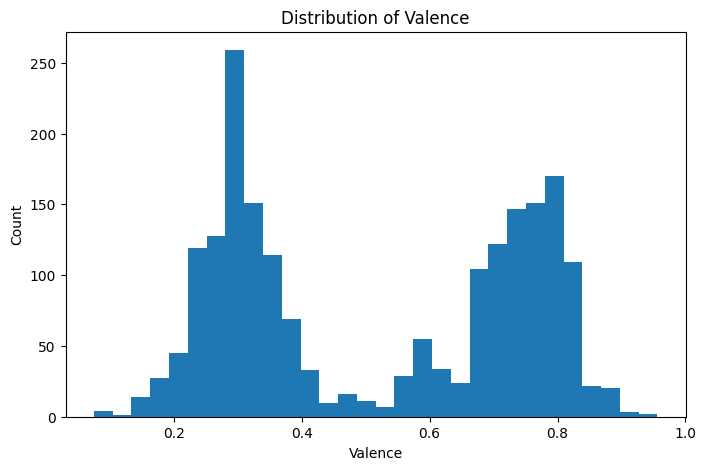

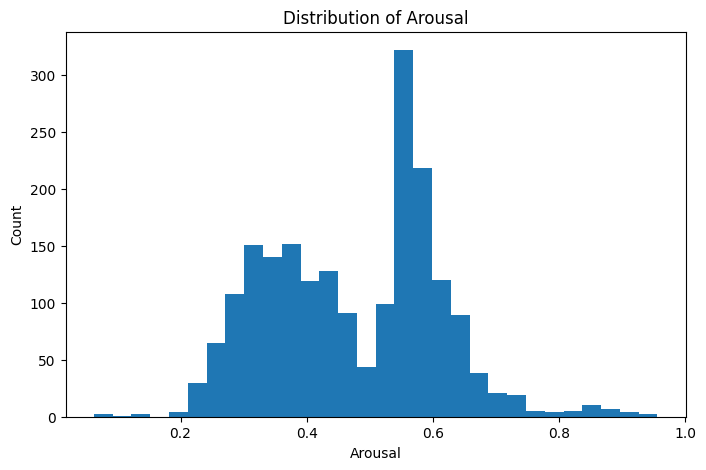


Split sizes:
Train: 1400
Validation: 300
Test: 300

Split percentages:
Train %: 0.7
Validation %: 0.15
Test %: 0.15

Saved files:
- train.csv
- test.csv
- val.csv


In [ ]:
show_statistics(final_df)
plot_distributions(final_df)

train_df, val_df, test_df = split_dataframe(final_df)
save_splits(train_df, val_df, test_df, SAVE_DIR)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

total = len(final_df)
print("\nSplit percentages:")
print("Train %:", len(train_df) / total)
print("Validation %:", len(val_df) / total)
print("Test %:", len(test_df) / total)

print("\nSaved files:")
for p in SAVE_DIR.iterdir():
    print("-", p.name)

The dataset contains 2000 clean samples with no missing values. Valence and arousal values are reasonably distributed, showing a mix of different emotional levels.

Valence and arousal values in this dataset are represented in the range \([0, 1]\). Valence measures how positive or negative an emotion is, while arousal measures the level of energy or intensity.

Although there are no negative numbers, this does not mean that negative emotions are absent. Instead, the midpoint (around 0.5) represents a neutral state. Values below 0.5 correspond to more negative emotions (such as sadness or anger), while values above 0.5 correspond to more positive emotions (such as happiness or excitement).

This means the dataset still captures the full emotional spectrum, but it is scaled differently compared to the typical \([-1, 1]\) representation.

The data was split into training (70%), validation (15%), and test (15%) sets. This setup allows proper training, tuning, and evaluation in the next phases.

## Phase 2 — Feature Extraction

I converted the raw audio and text data into numerical representations. I extracted audio embeddings using a pretrained MERT model and generated lyrics embeddings using Sentence-BERT.


In [ ]:
# ============================================================
# PHASE 2 — FEATURE EXTRACTION
# Goal:
# Convert each song into:
#   1) an audio embedding
#   2) a lyrics embedding
# while keeping valence/arousal labels
# Inputs:
#   - final_df (from Phase 1) with:
#       song_id, audio_path, lyrics, valence, arousal
#
# Outputs:
#   - phase2_df (clean metadata)
#   - audio_embeddings.npy
#   - lyrics_embeddings.npy
#   - fused_embeddings.npy
#   - phase2_features.npz (all combined)
# ============================================================

# -----------------------------
# 1. Install required packages
# -----------------------------
!pip -q install transformers==4.44.0 sentence-transformers torchaudio tqdm pyarrow

# -----------------------------
# 2. Imports
# -----------------------------
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm.auto import tqdm
from transformers import AutoModel, Wav2Vec2FeatureExtractor
from sentence_transformers import SentenceTransformer

# -----------------------------
# 3. Setup
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PHASE2_DIR = Path("/content/data/phase2_features")
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

required_cols = ["song_id", "audio_path", "lyrics", "valence", "arousal"]
missing_cols = [col for col in required_cols if col not in final_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in final_df: {missing_cols}")

print("final_df shape:", final_df.shape)
display(final_df[required_cols].head())

# ============================================================
# 4. Load pretrained models
# ============================================================

# Audio model: MERT
audio_model_name = "m-a-p/MERT-v1-95M"
audio_processor = Wav2Vec2FeatureExtractor.from_pretrained(
    audio_model_name,
    trust_remote_code=True
)
audio_model = AutoModel.from_pretrained(
    audio_model_name,
    trust_remote_code=True
).to(device)
audio_model.eval()

target_sr = audio_processor.sampling_rate
print("Target sample rate for MERT:", target_sr)

# Lyrics model: Sentence-BERT
lyrics_model_name = "sentence-transformers/all-MiniLM-L6-v2"
lyrics_model = SentenceTransformer(lyrics_model_name, device=device)





Using device: cuda
final_df shape: (2000, 5)


,song_id,audio_path,lyrics,valence,arousal
0,A001,/content/data/extracted/MERGE_Bimodal_Balanced...,"I see trees of green, red roses too\nI see the...",0.89375,0.29375
1,A002,/content/data/extracted/MERGE_Bimodal_Balanced...,Soon the pines will be falling everywhere\nVil...,0.68125,0.33750
2,A003,/content/data/extracted/MERGE_Bimodal_Balanced...,Lately I have had the strangest feeling\nWith ...,0.22500,0.25000
3,A004,/content/data/extracted/MERGE_Bimodal_Balanced...,Hear that lonesome whippoorwill?\nHe sounds to...,0.18125,0.20000
4,A005,/content/data/extracted/MERGE_Bimodal_Balanced...,Here we are folks\nThe dream we all dream off\...,0.68750,0.78750


Some weights of the model checkpoint at m-a-p/MERT-v1-95M were not used when initializing MERTModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing MERTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing MERTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of MERTModel were not initialized from the model checkpoint at m-a-p/MERT-v1-95M and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Target sample rate for MERT: 24000


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# ============================================================
# 5. Helper functions
# ============================================================

def load_audio_mono(audio_path, target_sr):
    """
    Load an audio file, convert it to mono, and resample it.
    """
    waveform, sr = torchaudio.load(audio_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != target_sr:
        waveform = torchaudio.transforms.Resample(sr, target_sr)(waveform)

    return waveform.squeeze(0), target_sr


def extract_audio_embedding(audio_path, processor, model, target_sr, chunk_seconds=15, max_chunks=20):
    """
    Extract one song-level audio embedding using MERT.
    """
    waveform, sr = load_audio_mono(audio_path, target_sr)
    chunk_size = chunk_seconds * sr
    chunks = []

    for start in range(0, len(waveform), chunk_size):
        chunk = waveform[start:start + chunk_size]
        if len(chunk) < sr:  # skip chunks shorter than 1 second
            continue
        chunks.append(chunk)
        if len(chunks) >= max_chunks:
            break

    if not chunks:
        return np.zeros(model.config.hidden_size, dtype=np.float32)

    chunk_embeddings = []

    with torch.no_grad():
        for chunk in chunks:
            inputs = processor(chunk.numpy(), sampling_rate=sr, return_tensors="pt")
            input_values = inputs["input_values"].to(device)

            outputs = model(input_values=input_values)
            embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy().astype(np.float32)
            chunk_embeddings.append(embedding)

    return np.mean(chunk_embeddings, axis=0).astype(np.float32)


def clean_lyrics(text):
    """
    Clean lyrics text before encoding.
    """
    if pd.isna(text):
        return ""
    text = str(text).replace("\r", "\n")
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()


def chunk_text_by_words(text, max_words=180):
    """
    Split lyrics into chunks to avoid truncation.
    """
    words = text.split()
    if not words:
        return [""]
    return [" ".join(words[i:i + max_words]) for i in range(0, len(words), max_words)]


def extract_lyrics_embedding(text, model, max_words=180):
    """
    Extract one song-level lyrics embedding using Sentence-BERT.
    """
    text = clean_lyrics(text)

    if text == "":
        return np.zeros(model.get_sentence_embedding_dimension(), dtype=np.float32)

    chunks = chunk_text_by_words(text, max_words=max_words)
    embeddings = model.encode(chunks, convert_to_numpy=True, show_progress_bar=False).astype(np.float32)

    return embeddings.mean(axis=0).astype(np.float32)

In [ ]:
# ============================================================
# 6. Extract features for all songs
# ============================================================

audio_embeddings = []
lyrics_embeddings = []
valid_rows = []

for idx, row in tqdm(final_df.iterrows(), total=len(final_df), desc="Extracting features"):
    audio_path = row["audio_path"]

    try:
        if pd.isna(audio_path) or not Path(audio_path).exists():
            print(f"Skipping {row['song_id']}: audio file not found -> {audio_path}")
            continue

        audio_embeddings.append(
            extract_audio_embedding(
                audio_path=audio_path,
                processor=audio_processor,
                model=audio_model,
                target_sr=target_sr
            )
        )

        lyrics_embeddings.append(
            extract_lyrics_embedding(
                text=row["lyrics"],
                model=lyrics_model
            )
        )

        valid_rows.append(idx)

    except Exception as e:
        print(f"Error processing {row['song_id']}: {e}")



Extracting features:   0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 7. Build final Phase 2 outputs
# ============================================================

phase2_df = final_df.loc[valid_rows, required_cols].reset_index(drop=True)

audio_embeddings = np.vstack(audio_embeddings) if audio_embeddings else np.empty(
    (0, audio_model.config.hidden_size), dtype=np.float32
)

lyrics_embeddings = np.vstack(lyrics_embeddings) if lyrics_embeddings else np.empty(
    (0, lyrics_model.get_sentence_embedding_dimension()), dtype=np.float32
)

fused_embeddings = np.concatenate([audio_embeddings, lyrics_embeddings], axis=1)

print("phase2_df shape:", phase2_df.shape)
print("audio_embeddings shape:", audio_embeddings.shape)
print("lyrics_embeddings shape:", lyrics_embeddings.shape)
print("fused_embeddings shape:", fused_embeddings.shape)

# ============================================================
# 8. Save outputs
# ============================================================

phase2_df.to_parquet(PHASE2_DIR / "phase2_metadata.parquet", index=False)
np.save(PHASE2_DIR / "audio_embeddings.npy", audio_embeddings)
np.save(PHASE2_DIR / "lyrics_embeddings.npy", lyrics_embeddings)
np.save(PHASE2_DIR / "fused_embeddings.npy", fused_embeddings)

np.savez_compressed(
    PHASE2_DIR / "phase2_features.npz",
    song_id=phase2_df["song_id"].astype(str).values,
    valence=phase2_df["valence"].values,
    arousal=phase2_df["arousal"].values,
    audio_embeddings=audio_embeddings,
    lyrics_embeddings=lyrics_embeddings,
    fused_embeddings=fused_embeddings
)

print(f"Saved Phase 2 outputs to: {PHASE2_DIR}")

# ============================================================
# 9. Quick sanity check
# ============================================================

print("\nSanity check:")
print("First song ID:", phase2_df.loc[0, "song_id"] if len(phase2_df) > 0 else "N/A")
print("Audio embedding dim:", audio_embeddings.shape[1] if len(audio_embeddings) > 0 else "N/A")
print("Lyrics embedding dim:", lyrics_embeddings.shape[1] if len(lyrics_embeddings) > 0 else "N/A")
print("Fused embedding dim:", fused_embeddings.shape[1] if len(fused_embeddings) > 0 else "N/A")

phase2_df shape: (2000, 5)
audio_embeddings shape: (2000, 768)
lyrics_embeddings shape: (2000, 384)
fused_embeddings shape: (2000, 1152)
Saved Phase 2 outputs to: /content/data/phase2_features

Sanity check:
First song ID: A001
Audio embedding dim: 768
Lyrics embedding dim: 384
Fused embedding dim: 1152


## Phase 3 — Baseline Models

I trained simple models using only audio or only lyrics to predict valence and arousal. These models were used to establish baseline performance for comparison.


In [ ]:
# ============================================================
# PHASE 3 — BASELINE MODELS
# Goal:
#   Establishing reference performance using simple unimodal models:
#   1) lyrics-only baseline
#   2) audio-only baseline
#
# Each baseline predicts:
#   - valence
#   - arousal
# independently.
#
# Creating a small set of report-ready plots:
#   1) RMSE comparison bar chart
#   2) predicted vs true for valence
#   3) predicted vs true for arousal
#
# Inputs:
#   - phase2_metadata.parquet (metadata with valence/arousal)
#   - audio_embeddings.npy (audio features)
#   - lyrics_embeddings.npy (lyrics features)
#
# Outputs:
#   - baseline_results.csv (evaluation metrics)
#   - prediction .npy files
#   - RMSE comparison plot
#   - predicted vs true plots
# ============================================================

# -----------------------------
# 1. Imports
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 2. Paths
# -----------------------------
# Define directories for loading inputs and saving outputs
DATA_DIR = Path("/content/data")
PHASE2_DIR = DATA_DIR / "phase2_features"
PHASE3_DIR = DATA_DIR / "phase3_baselines"
PLOTS_DIR = PHASE3_DIR / "plots"

# Create directories if they do not exist
PHASE3_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Loading Phase 2 outputs
# -----------------------------
# Load metadata and embeddings generated in Phase 2
phase2_df = pd.read_parquet(PHASE2_DIR / "phase2_metadata.parquet")
audio_embeddings = np.load(PHASE2_DIR / "audio_embeddings.npy")
lyrics_embeddings = np.load(PHASE2_DIR / "lyrics_embeddings.npy")

# Print shapes to verify everything loaded correctly
print("Metadata shape:", phase2_df.shape)
print("Audio embeddings shape:", audio_embeddings.shape)
print("Lyrics embeddings shape:", lyrics_embeddings.shape)



Metadata shape: (2000, 5)
Audio embeddings shape: (2000, 768)
Lyrics embeddings shape: (2000, 384)


In [ ]:
# -----------------------------
# 4. Preparing features and targets
# -----------------------------
# Define feature sets for each baseline model
features = {
    "Lyrics-only": lyrics_embeddings,
    "Audio-only": audio_embeddings
}

# Define prediction targets (regression)
targets = {
    "Valence": phase2_df["valence"].values,
    "Arousal": phase2_df["arousal"].values
}

# -----------------------------
# 5. Creating shared train/test split
# -----------------------------
# Use same split for all models
indices = np.arange(len(phase2_df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Print split sizes
print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

Train size: 1600
Test size: 400


In [ ]:
# -----------------------------
# 6. Defining helpers
# -----------------------------
def evaluate_regression(y_true, y_pred):
    """
    Compute regression metrics:
    - MSE
    - RMSE
    - MAE
    - R²
    """
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def plot_predicted_vs_true(y_true, y_pred_lyrics, y_pred_audio, target_name, filename):
    """
    Plot predicted vs true values for both baselines.
    """
    # Define axis limits
    min_val = min(y_true.min(), y_pred_lyrics.min(), y_pred_audio.min())
    max_val = max(y_true.max(), y_pred_lyrics.max(), y_pred_audio.max())

    plt.figure(figsize=(6, 6))

    # Scatter plots for both models
    plt.scatter(y_true, y_pred_lyrics, alpha=0.5, label="Lyrics-only")
    plt.scatter(y_true, y_pred_audio, alpha=0.5, label="Audio-only")

    # Ideal prediction line (y = x)
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"Predicted vs True — {target_name}")
    plt.legend()

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# -----------------------------
# 7. Training baselines
# -----------------------------
# Store results and predictions
results = []
predictions = {}
y_test_values = {}

# Loop over each model and each target
for model_name, X in features.items():
    X_train = X[train_idx]
    X_test = X[test_idx]

    for target_name, y in targets.items():
        y_train = y[train_idx]
        y_test = y[test_idx]

        # Train Ridge regression model
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)

        # Predict on test set
        y_pred = model.predict(X_test)

        # Evaluate predictions
        metrics = evaluate_regression(y_test, y_pred)

        # Print results
        print(f"\n[{model_name} | {target_name}]")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value:.4f}")

        # Store results
        results.append({
            "Model": model_name,
            "Target": target_name,
            **metrics
        })

        # Store predictions for later
        predictions[f"{model_name}_{target_name}"] = y_pred
        y_test_values[target_name] = y_test

# -----------------------------
# 8. Creating summary table
# -----------------------------
# Convert results into a DataFrame
results_df = pd.DataFrame(results)

print("\nBaseline Results Summary:")
display(results_df)


[Lyrics-only | Valence]
MSE: 0.0284
RMSE: 0.1685
MAE: 0.1345
R2: 0.4511

[Lyrics-only | Arousal]
MSE: 0.0137
RMSE: 0.1172
MAE: 0.0883
R2: 0.2759

[Audio-only | Valence]
MSE: 0.0348
RMSE: 0.1865
MAE: 0.1519
R2: 0.3274

[Audio-only | Arousal]
MSE: 0.0109
RMSE: 0.1045
MAE: 0.0783
R2: 0.4247

Baseline Results Summary:


,Model,Target,MSE,RMSE,MAE,R2
0,Lyrics-only,Valence,0.028379,0.168460,0.134535,0.451096
1,Lyrics-only,Arousal,0.013736,0.117199,0.088327,0.275950
2,Audio-only,Valence,0.034776,0.186482,0.151932,0.327365
3,Audio-only,Arousal,0.010914,0.104470,0.078333,0.424690


In [ ]:
# -----------------------------
# 9. Saving results
# -----------------------------
# Save evaluation metrics
results_df.to_csv(PHASE3_DIR / "baseline_results.csv", index=False)

# Save predictions for next phases
np.save(PHASE3_DIR / "lyrics_valence_pred.npy", predictions["Lyrics-only_Valence"])
np.save(PHASE3_DIR / "lyrics_arousal_pred.npy", predictions["Lyrics-only_Arousal"])
np.save(PHASE3_DIR / "audio_valence_pred.npy", predictions["Audio-only_Valence"])
np.save(PHASE3_DIR / "audio_arousal_pred.npy", predictions["Audio-only_Arousal"])
np.save(PHASE3_DIR / "test_indices.npy", test_idx)

print(f"\nSaved baseline outputs to: {PHASE3_DIR}")


Saved baseline outputs to: /content/data/phase3_baselines


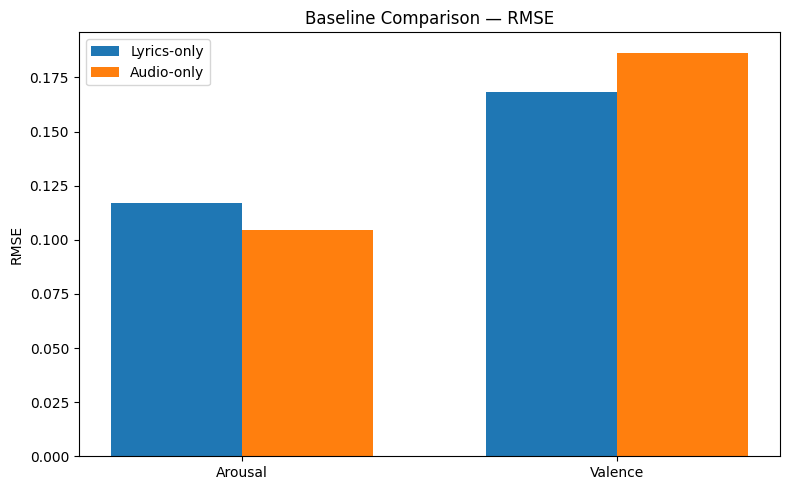

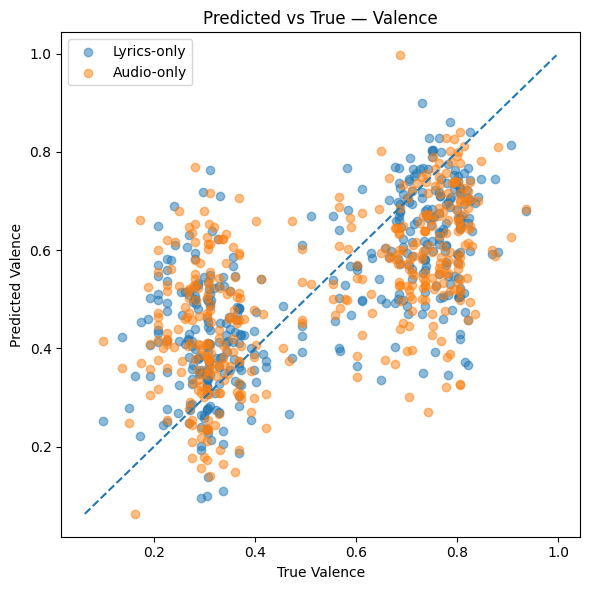

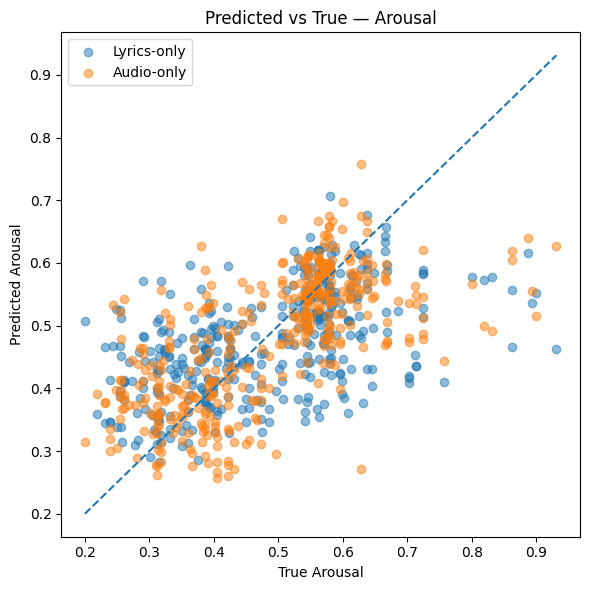

Saved plots to: /content/data/phase3_baselines/plots


In [ ]:

# -----------------------------
# 10. Creating RMSE comparison plot
# -----------------------------
# Reshape results for plotting
rmse_df = results_df.pivot(index="Target", columns="Model", values="RMSE")

x = np.arange(len(rmse_df.index))
width = 0.35

plt.figure(figsize=(8, 5))

# Plot bars for each model
plt.bar(x - width / 2, rmse_df["Lyrics-only"], width, label="Lyrics-only")
plt.bar(x + width / 2, rmse_df["Audio-only"], width, label="Audio-only")

plt.xticks(x, rmse_df.index)
plt.ylabel("RMSE")
plt.title("Baseline Comparison — RMSE")
plt.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "baseline_rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 11. Creating predicted vs true plots
# -----------------------------
# Plot Valence predictions
plot_predicted_vs_true(
    y_true=y_test_values["Valence"],
    y_pred_lyrics=predictions["Lyrics-only_Valence"],
    y_pred_audio=predictions["Audio-only_Valence"],
    target_name="Valence",
    filename="valence_predicted_vs_true.png"
)

# Plot Arousal predictions
plot_predicted_vs_true(
    y_true=y_test_values["Arousal"],
    y_pred_lyrics=predictions["Lyrics-only_Arousal"],
    y_pred_audio=predictions["Audio-only_Arousal"],
    target_name="Arousal",
    filename="arousal_predicted_vs_true.png"
)

print(f"Saved plots to: {PLOTS_DIR}")

## Phase 4 — Multimodal Model

I built a neural network that combines audio and lyrics embeddings. This model learns from both modalities to improve valence–arousal prediction.


In [ ]:
# ============================================================
# PHASE 4 — MULTIMODAL MODEL
# Goal:
#   Combine audio and lyrics embeddings in a neural network
#   to improve valence and arousal prediction.
#
# Creating a multimodal regressor that:
#   1) processes audio embeddings through one branch
#   2) processes lyrics embeddings through another branch
#   3) fuses both branches into a shared representation
#   4) predicts:
#        - valence
#        - arousal
#
# Inputs:
#   - phase2_metadata.parquet
#   - audio_embeddings.npy
#   - lyrics_embeddings.npy
#   - train.csv / val.csv / test.csv (Phase 1 splits)
#
# Outputs:
#   - multimodal_model.pt
#   - training_history.csv
#   - multimodal_results.csv
#   - prediction files (.npy and .csv)
#   - plots (training history, predictions, RMSE)
# ============================================================

# -----------------------------
# 1. Install required packages
# -----------------------------
!pip -q install torch

# -----------------------------
# 2. Imports
# -----------------------------
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 3. Paths
# -----------------------------
DATA_DIR = Path("/content/data")
PHASE1_DIR = DATA_DIR / "splits"
PHASE2_DIR = DATA_DIR / "phase2_features"
PHASE4_DIR = DATA_DIR / "phase4_multimodal_model"
PLOTS_DIR = PHASE4_DIR / "plots"

PHASE4_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 4. Reproducibility and device
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:

# -----------------------------
# 5. Load Phase 2 features
# -----------------------------

# Load metadata and embeddings generated in Phase 2
metadata_path = PHASE2_DIR / "phase2_metadata.parquet"
audio_path = PHASE2_DIR / "audio_embeddings.npy"
lyrics_path = PHASE2_DIR / "lyrics_embeddings.npy"

phase2_df = pd.read_parquet(metadata_path).reset_index(drop=True)
audio_embeddings = np.load(audio_path)
lyrics_embeddings = np.load(lyrics_path)

# Print shapes to verify loading
print("phase2_df shape:", phase2_df.shape)
print("audio_embeddings shape:", audio_embeddings.shape)
print("lyrics_embeddings shape:", lyrics_embeddings.shape)

# -----------------------------
# 6. Load Phase 1 splits
# -----------------------------

# Load train/validation/test splits
train_df = pd.read_csv(PHASE1_DIR / "train.csv")
val_df = pd.read_csv(PHASE1_DIR / "val.csv")
test_df = pd.read_csv(PHASE1_DIR / "test.csv")

# Print split sizes
print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

# -----------------------------
# 7. Attach split labels to Phase 2 metadata
# -----------------------------
# Map each song_id to its split

split_map = {}

for sid in train_df["song_id"].tolist():
    split_map[sid] = "train"

for sid in val_df["song_id"].tolist():
    split_map[sid] = "val"

for sid in test_df["song_id"].tolist():
    split_map[sid] = "test"

phase2_df["split"] = phase2_df["song_id"].map(split_map)

phase2_df = phase2_df.dropna(subset=["split"]).reset_index(drop=True)

# Display split distribution
print("\nSplit counts inside phase2_df:")
print(phase2_df["split"].value_counts())

phase2_df shape: (2000, 5)
audio_embeddings shape: (2000, 768)
lyrics_embeddings shape: (2000, 384)
train_df shape: (1400, 5)
val_df shape: (300, 5)
test_df shape: (300, 5)

Split counts inside phase2_df:
split
train    1400
test      300
val       300
Name: count, dtype: int64


In [ ]:
# -----------------------------
# 8. Align arrays with metadata
# -----------------------------

# Ensure embeddings match metadata rows
assert len(phase2_df) == len(audio_embeddings), "Mismatch between metadata and audio embeddings."
assert len(phase2_df) == len(lyrics_embeddings), "Mismatch between metadata and lyrics embeddings."

# -----------------------------
# 9. Build train / val / test arrays
# -----------------------------

# Create masks for splits
train_mask = phase2_df["split"] == "train"
val_mask = phase2_df["split"] == "val"
test_mask = phase2_df["split"] == "test"

# Split audio features
X_audio_train = audio_embeddings[train_mask.values]
X_audio_val = audio_embeddings[val_mask.values]
X_audio_test = audio_embeddings[test_mask.values]

# Split lyrics features
X_lyrics_train = lyrics_embeddings[train_mask.values]
X_lyrics_val = lyrics_embeddings[val_mask.values]
X_lyrics_test = lyrics_embeddings[test_mask.values]

# Targets (valence and arousal)
y_train = phase2_df.loc[train_mask, ["valence", "arousal"]].values.astype(np.float32)
y_val = phase2_df.loc[val_mask, ["valence", "arousal"]].values.astype(np.float32)
y_test = phase2_df.loc[test_mask, ["valence", "arousal"]].values.astype(np.float32)

# Print shapes
print("\nTrain shapes:")
print("Audio:", X_audio_train.shape, "| Lyrics:", X_lyrics_train.shape, "| y:", y_train.shape)

print("\nValidation shapes:")
print("Audio:", X_audio_val.shape, "| Lyrics:", X_lyrics_val.shape, "| y:", y_val.shape)

print("\nTest shapes:")
print("Audio:", X_audio_test.shape, "| Lyrics:", X_lyrics_test.shape, "| y:", y_test.shape)


Train shapes:
Audio: (1400, 768) | Lyrics: (1400, 384) | y: (1400, 2)

Validation shapes:
Audio: (300, 768) | Lyrics: (300, 384) | y: (300, 2)

Test shapes:
Audio: (300, 768) | Lyrics: (300, 384) | y: (300, 2)


In [ ]:
# -----------------------------
# 10. Standardize embeddings
# -----------------------------

# Normalize features using training statistics only
audio_mean = X_audio_train.mean(axis=0, keepdims=True)
audio_std = X_audio_train.std(axis=0, keepdims=True) + 1e-8

lyrics_mean = X_lyrics_train.mean(axis=0, keepdims=True)
lyrics_std = X_lyrics_train.std(axis=0, keepdims=True) + 1e-8

# Apply normalization
X_audio_train = (X_audio_train - audio_mean) / audio_std
X_audio_val = (X_audio_val - audio_mean) / audio_std
X_audio_test = (X_audio_test - audio_mean) / audio_std

X_lyrics_train = (X_lyrics_train - lyrics_mean) / lyrics_std
X_lyrics_val = (X_lyrics_val - lyrics_mean) / lyrics_std
X_lyrics_test = (X_lyrics_test - lyrics_mean) / lyrics_std

In [ ]:
# -----------------------------
# 11. Dataset and dataloaders
# -----------------------------

# Custom dataset for multimodal inputs
class MultimodalEmotionDataset(Dataset):
    def __init__(self, audio_features, lyrics_features, targets):
        self.audio_features = torch.tensor(audio_features, dtype=torch.float32)
        self.lyrics_features = torch.tensor(lyrics_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.audio_features[idx],
            self.lyrics_features[idx],
            self.targets[idx]
        )

BATCH_SIZE = 64

# Create datasets
train_dataset = MultimodalEmotionDataset(X_audio_train, X_lyrics_train, y_train)
val_dataset = MultimodalEmotionDataset(X_audio_val, X_lyrics_val, y_val)
test_dataset = MultimodalEmotionDataset(X_audio_test, X_lyrics_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# -----------------------------
# 12. Define multimodal model
# -----------------------------

# Neural network with:
# - one branch for audio embeddings
# - one branch for lyrics embeddings
# - one fusion head to combine both branches
# - final output of size 2: [valence, arousal]

class MultimodalRegressor(nn.Module):
    def __init__(self, audio_dim, lyrics_dim):
        super().__init__()

        self.audio_branch = nn.Sequential(
            nn.Linear(audio_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.lyrics_branch = nn.Sequential(
            nn.Linear(lyrics_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(128 + 128, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)   # [valence, arousal]
        )

    def forward(self, audio_x, lyrics_x):
        audio_repr = self.audio_branch(audio_x)
        lyrics_repr = self.lyrics_branch(lyrics_x)
        fused = torch.cat([audio_repr, lyrics_repr], dim=1)
        output = self.fusion_head(fused)
        return output

audio_dim = X_audio_train.shape[1]
lyrics_dim = X_lyrics_train.shape[1]

model = MultimodalRegressor(audio_dim=audio_dim, lyrics_dim=lyrics_dim).to(device)
print(model)

MultimodalRegressor(
  (audio_branch): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (lyrics_branch): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (fusion_head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
# -----------------------------
# 13. Training setup
# -----------------------------
# Loss function for regression
criterion = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Maximum number of epochs and early stopping
EPOCHS = 100
PATIENCE = 10

# Store training history for plotting
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": []
}

# Track best validation loss and model state
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

# -----------------------------
# 14. Training loop
# -----------------------------
# Train model epoch by epoch
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    # Training pass
    for batch_audio, batch_lyrics, batch_targets in train_loader:
        batch_audio = batch_audio.to(device)
        batch_lyrics = batch_lyrics.to(device)
        batch_targets = batch_targets.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        preds = model(batch_audio, batch_lyrics)
        loss = criterion(preds, batch_targets)

        # Backpropagation + parameter update
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    # Validation pass
    with torch.no_grad():
        for batch_audio, batch_lyrics, batch_targets in val_loader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)
            batch_targets = batch_targets.to(device)

            preds = model(batch_audio, batch_lyrics)
            loss = criterion(preds, batch_targets)

            val_losses.append(loss.item())

    # Average losses for this epoch
    avg_train_loss = float(np.mean(train_losses))
    avg_val_loss = float(np.mean(val_losses))

    # Save history
    history["epoch"].append(epoch)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Keep best model based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Stop early if validation loss stops improving
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# -----------------------------
# 15. Load best model
# -----------------------------
# Restore the best model found during training
model.load_state_dict(best_state)

Epoch 001 | Train Loss: 0.117080 | Val Loss: 0.034864
Epoch 002 | Train Loss: 0.038252 | Val Loss: 0.028471
Epoch 003 | Train Loss: 0.030351 | Val Loss: 0.023103
Epoch 004 | Train Loss: 0.024535 | Val Loss: 0.018905
Epoch 005 | Train Loss: 0.022426 | Val Loss: 0.018696
Epoch 006 | Train Loss: 0.020212 | Val Loss: 0.018205
Epoch 007 | Train Loss: 0.019303 | Val Loss: 0.018251
Epoch 008 | Train Loss: 0.017870 | Val Loss: 0.018041
Epoch 009 | Train Loss: 0.017078 | Val Loss: 0.018234
Epoch 010 | Train Loss: 0.015116 | Val Loss: 0.017723
Epoch 011 | Train Loss: 0.014686 | Val Loss: 0.018078
Epoch 012 | Train Loss: 0.013140 | Val Loss: 0.018572
Epoch 013 | Train Loss: 0.013649 | Val Loss: 0.023739
Epoch 014 | Train Loss: 0.012464 | Val Loss: 0.018036
Epoch 015 | Train Loss: 0.011869 | Val Loss: 0.019256
Epoch 016 | Train Loss: 0.010321 | Val Loss: 0.019081
Epoch 017 | Train Loss: 0.009798 | Val Loss: 0.019924
Epoch 018 | Train Loss: 0.009089 | Val Loss: 0.019665
Epoch 019 | Train Loss: 0.00

<All keys matched successfully>

In [ ]:
# -----------------------------
# 16. Save training history
# -----------------------------
# Save loss history as CSV
history_df = pd.DataFrame(history)
history_df.to_csv(PHASE4_DIR / "training_history.csv", index=False)

# Save trained model weights
torch.save(model.state_dict(), PHASE4_DIR / "multimodal_model.pt")

print("\nSaved:")
print("-", PHASE4_DIR / "training_history.csv")
print("-", PHASE4_DIR / "multimodal_model.pt")


Saved:
- /content/data/phase4_multimodal_model/training_history.csv
- /content/data/phase4_multimodal_model/multimodal_model.pt


In [ ]:

# -----------------------------
# 17. Prediction helper
# -----------------------------
# Helper function to run inference on a dataloader
def predict_model(model, dataloader, device):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for batch_audio, batch_lyrics, batch_targets in dataloader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)

            # Predict on batch
            preds = model(batch_audio, batch_lyrics).cpu().numpy()

            preds_list.append(preds)
            targets_list.append(batch_targets.numpy())

    # Stack all batches into full arrays
    preds_all = np.vstack(preds_list)
    targets_all = np.vstack(targets_list)
    return preds_all, targets_all

# Get predictions for validation and test sets
val_preds, val_true = predict_model(model, val_loader, device)
test_preds, test_true = predict_model(model, test_loader, device)

# -----------------------------
# 18. Evaluation metrics
# -----------------------------
# Compute regression metrics for a single target
def regression_metrics(y_true, y_pred, target_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "target": target_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

results = []

# Evaluate validation and test predictions separately
results.append(regression_metrics(val_true[:, 0], val_preds[:, 0], "valence_val"))
results.append(regression_metrics(val_true[:, 1], val_preds[:, 1], "arousal_val"))
results.append(regression_metrics(test_true[:, 0], test_preds[:, 0], "valence_test"))
results.append(regression_metrics(test_true[:, 1], test_preds[:, 1], "arousal_test"))

# Save metrics table
results_df = pd.DataFrame(results)
results_df.to_csv(PHASE4_DIR / "multimodal_results.csv", index=False)

print("\nEvaluation results:")
print(results_df)

# -----------------------------
# 19. Save predictions
# -----------------------------
# Save raw prediction arrays
np.save(PHASE4_DIR / "val_predictions.npy", val_preds)
np.save(PHASE4_DIR / "val_true.npy", val_true)
np.save(PHASE4_DIR / "test_predictions.npy", test_preds)
np.save(PHASE4_DIR / "test_true.npy", test_true)

# Save test predictions in CSV format for easier inspection
predictions_df = pd.DataFrame({
    "song_id": phase2_df.loc[test_mask, "song_id"].values,
    "true_valence": test_true[:, 0],
    "pred_valence": test_preds[:, 0],
    "true_arousal": test_true[:, 1],
    "pred_arousal": test_preds[:, 1],
})
predictions_df.to_csv(PHASE4_DIR / "test_predictions.csv", index=False)

print("\nSaved prediction files.")


Evaluation results:
         target       MSE      RMSE       MAE        R2
0   valence_val  0.026718  0.163456  0.127165  0.474509
1   arousal_val  0.009003  0.094885  0.067155  0.491308
2  valence_test  0.027088  0.164586  0.129209  0.491198
3  arousal_test  0.009992  0.099958  0.073777  0.483458

Saved prediction files.


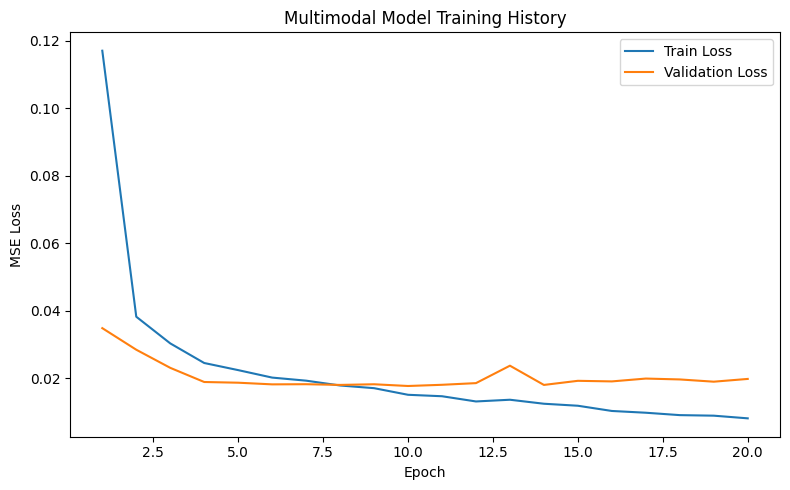

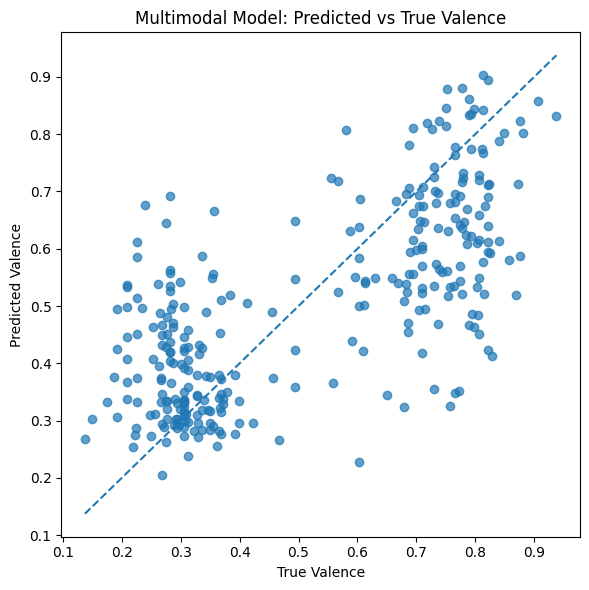

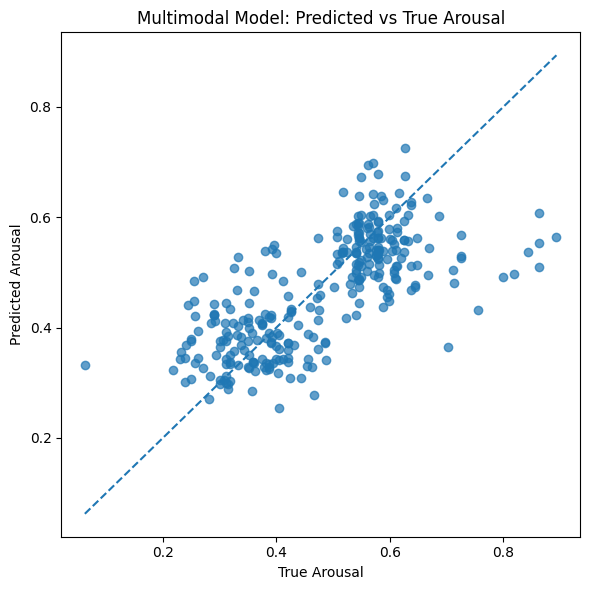

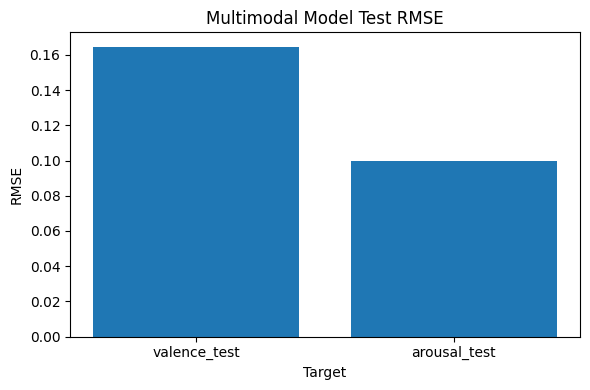


Phase 4 complete.
Artifacts saved in: /content/data/phase4_multimodal_model
Plots saved in: /content/data/phase4_multimodal_model/plots


In [ ]:
# -----------------------------
# 20. Plot: training history
# -----------------------------
# Plot training and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Multimodal Model Training History")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_history.png", dpi=300)
plt.show()

# -----------------------------
# 21. Plot: predicted vs true (valence)
# -----------------------------
# Scatter plot for valence predictions on test set
plt.figure(figsize=(6, 6))
plt.scatter(test_true[:, 0], test_preds[:, 0], alpha=0.7)
min_v = min(test_true[:, 0].min(), test_preds[:, 0].min())
max_v = max(test_true[:, 0].max(), test_preds[:, 0].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("True Valence")
plt.ylabel("Predicted Valence")
plt.title("Multimodal Model: Predicted vs True Valence")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valence_predicted_vs_true.png", dpi=300)
plt.show()

# -----------------------------
# 22. Plot: predicted vs true (arousal)
# -----------------------------
# Scatter plot for arousal predictions on test set
plt.figure(figsize=(6, 6))
plt.scatter(test_true[:, 1], test_preds[:, 1], alpha=0.7)
min_a = min(test_true[:, 1].min(), test_preds[:, 1].min())
max_a = max(test_true[:, 1].max(), test_preds[:, 1].max())
plt.plot([min_a, max_a], [min_a, max_a], linestyle="--")
plt.xlabel("True Arousal")
plt.ylabel("Predicted Arousal")
plt.title("Multimodal Model: Predicted vs True Arousal")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "arousal_predicted_vs_true.png", dpi=300)
plt.show()

# -----------------------------
# 23. Plot: RMSE summary
# -----------------------------
# Keep only test-set rows for RMSE plot
test_only = results_df[results_df["target"].isin(["valence_test", "arousal_test"])].copy()

# Plot test RMSE for both targets
plt.figure(figsize=(6, 4))
plt.bar(test_only["target"], test_only["RMSE"])
plt.xlabel("Target")
plt.ylabel("RMSE")
plt.title("Multimodal Model Test RMSE")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "multimodal_test_rmse.png", dpi=300)
plt.show()

# -----------------------------
# 24. Final summary
# -----------------------------
# Final confirmation of saved outputs
print("\nPhase 4 complete.")
print("Artifacts saved in:", PHASE4_DIR)
print("Plots saved in:", PLOTS_DIR)

## Phase 5 — Hyperpatameter Tuning


I optimized the multimodal model by testing different hyperparameters such as learning rate, hidden layer size, dropout, and batch size using the validation set.


In [ ]:
# ============================================================
# PHASE 5 — HYPERPARAMETER TUNING
# Goal:
#   Optimize the multimodal valence-arousal model using
#   validation-only hyperparameter tuning.
#
# This phase:
#   1) loads Phase 2 embeddings
#   2) loads Phase 1 train / validation splits
#   3) realigns embeddings to the split-filtered metadata
#   4) standardizes features using training statistics only
#   5) tunes:
#        - learning rate
#        - hidden layer size
#        - dropout
#        - batch size
#   6) selects the best configuration using validation loss only
#   7) saves tuning results, best config, best model, and plots
#
#
# Inputs:
#   - phase2_metadata.parquet
#   - audio_embeddings.npy
#   - lyrics_embeddings.npy
#   - train.csv / val.csv
#
# Outputs:
#   - tuning_results.csv
#   - best_hyperparameters.json
#   - best_tuned_model.pt
#   - best_training_history.csv
#   - best_val_predictions (.npy + .csv)
#   - best_validation_metrics.csv
#   - plots (loss curves, RMSE, predictions)
# ============================================================

# -----------------------------
# 1. Install required packages
# -----------------------------
!pip -q install torch pyarrow

# -----------------------------
# 2. Imports
# -----------------------------
import copy
import json
import random
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 3. Paths
# -----------------------------
# Define directories
DATA_DIR = Path("/content/data")
PHASE1_DIR = DATA_DIR / "splits"
PHASE2_DIR = DATA_DIR / "phase2_features"
PHASE5_DIR = DATA_DIR / "phase5_hyperparameter_tuning"
PLOTS_DIR = PHASE5_DIR / "plots"

# Create output folders
PHASE5_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 4. Reproducibility and device
# -----------------------------
# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:

# -----------------------------
# 5. Load Phase 2 features
# -----------------------------
# Load full metadata and embeddings
phase2_df_full = pd.read_parquet(PHASE2_DIR / "phase2_metadata.parquet").reset_index(drop=True)
audio_embeddings_full = np.load(PHASE2_DIR / "audio_embeddings.npy")
lyrics_embeddings_full = np.load(PHASE2_DIR / "lyrics_embeddings.npy")

# Verify shapes
print("phase2_df_full shape:", phase2_df_full.shape)
print("audio_embeddings_full shape:", audio_embeddings_full.shape)
print("lyrics_embeddings_full shape:", lyrics_embeddings_full.shape)

# Ensure alignment
assert len(phase2_df_full) == len(audio_embeddings_full)
assert len(phase2_df_full) == len(lyrics_embeddings_full)

# -----------------------------
# 6. Load Phase 1 splits
# -----------------------------
# Load training and validation splits
train_df = pd.read_csv(PHASE1_DIR / "train.csv")
val_df = pd.read_csv(PHASE1_DIR / "val.csv")

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)

# -----------------------------
# 7. Attach split labels
# -----------------------------
# Map song_id -> split
split_map = {}

for sid in train_df["song_id"].tolist():
    split_map[sid] = "train"

for sid in val_df["song_id"].tolist():
    split_map[sid] = "val"

# Apply mapping
phase2_df = phase2_df_full.copy()
phase2_df["split"] = phase2_df["song_id"].map(split_map)

# Remove rows without split
phase2_df = phase2_df.dropna(subset=["split"]).reset_index(drop=True)

print("\nSplit counts inside phase2_df:")
print(phase2_df["split"].value_counts())

# -----------------------------
# 8. Realign embeddings to filtered metadata
# -----------------------------
# Ensure embeddings match filtered metadata order
source_ids = phase2_df_full["song_id"].tolist()
source_index = {sid: i for i, sid in enumerate(source_ids)}

ordered_ids = phase2_df["song_id"].tolist()
ordered_indices = [source_index[sid] for sid in ordered_ids]

audio_embeddings = audio_embeddings_full[ordered_indices]
lyrics_embeddings = lyrics_embeddings_full[ordered_indices]

print("\nAfter realignment:")
print("phase2_df shape:", phase2_df.shape)
print("audio_embeddings shape:", audio_embeddings.shape)
print("lyrics_embeddings shape:", lyrics_embeddings.shape)

phase2_df_full shape: (2000, 5)
audio_embeddings_full shape: (2000, 768)
lyrics_embeddings_full shape: (2000, 384)
train_df shape: (1400, 5)
val_df shape: (300, 5)

Split counts inside phase2_df:
split
train    1400
val       300
Name: count, dtype: int64

After realignment:
phase2_df shape: (1700, 6)
audio_embeddings shape: (1700, 768)
lyrics_embeddings shape: (1700, 384)


In [ ]:
# -----------------------------
# 9. Build train / val arrays
# -----------------------------
# Create masks
train_mask = phase2_df["split"] == "train"
val_mask = phase2_df["split"] == "val"

# Split features
X_audio_train = audio_embeddings[train_mask.values]
X_audio_val = audio_embeddings[val_mask.values]

X_lyrics_train = lyrics_embeddings[train_mask.values]
X_lyrics_val = lyrics_embeddings[val_mask.values]

# Targets
y_train = phase2_df.loc[train_mask, ["valence", "arousal"]].values.astype(np.float32)
y_val = phase2_df.loc[val_mask, ["valence", "arousal"]].values.astype(np.float32)

song_ids_val = phase2_df.loc[val_mask, "song_id"].values

# -----------------------------
# 10. Standardize embeddings
# -----------------------------
# Normalize using training statistics
audio_mean = X_audio_train.mean(axis=0, keepdims=True)
audio_std = X_audio_train.std(axis=0, keepdims=True) + 1e-8

lyrics_mean = X_lyrics_train.mean(axis=0, keepdims=True)
lyrics_std = X_lyrics_train.std(axis=0, keepdims=True) + 1e-8

X_audio_train = (X_audio_train - audio_mean) / audio_std
X_audio_val = (X_audio_val - audio_mean) / audio_std

X_lyrics_train = (X_lyrics_train - lyrics_mean) / lyrics_std
X_lyrics_val = (X_lyrics_val - lyrics_mean) / lyrics_std

# Save normalization parameters
np.save(PHASE5_DIR / "audio_mean.npy", audio_mean)
np.save(PHASE5_DIR / "audio_std.npy", audio_std)
np.save(PHASE5_DIR / "lyrics_mean.npy", lyrics_mean)
np.save(PHASE5_DIR / "lyrics_std.npy", lyrics_std)

In [ ]:

# -----------------------------
# 11. Dataset class
# -----------------------------
# PyTorch dataset for multimodal inputs
class MultimodalEmotionDataset(Dataset):
    def __init__(self, audio_features, lyrics_features, targets):
        self.audio_features = torch.tensor(audio_features, dtype=torch.float32)
        self.lyrics_features = torch.tensor(lyrics_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.audio_features[idx],
            self.lyrics_features[idx],
            self.targets[idx]
        )

# -----------------------------
# 12. Model definition
# -----------------------------
# Tunable multimodal architecture
class TunedMultimodalRegressor(nn.Module):
    def __init__(self, audio_dim, lyrics_dim, hidden_size=256, dropout=0.30):
        super().__init__()

        branch_hidden_1 = hidden_size
        branch_hidden_2 = max(hidden_size // 2, 32)
        fusion_hidden_1 = hidden_size
        fusion_hidden_2 = max(hidden_size // 4, 16)

        # Audio branch
        self.audio_branch = nn.Sequential(
            nn.Linear(audio_dim, branch_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_hidden_1, branch_hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Lyrics branch
        self.lyrics_branch = nn.Sequential(
            nn.Linear(lyrics_dim, branch_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_hidden_1, branch_hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Fusion head
        self.fusion_head = nn.Sequential(
            nn.Linear(branch_hidden_2 * 2, fusion_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_1, fusion_hidden_2),
            nn.ReLU(),
            nn.Linear(fusion_hidden_2, 2)
        )

    def forward(self, audio_x, lyrics_x):
        audio_repr = self.audio_branch(audio_x)
        lyrics_repr = self.lyrics_branch(lyrics_x)
        fused = torch.cat([audio_repr, lyrics_repr], dim=1)
        return self.fusion_head(fused)

In [ ]:

# -----------------------------
# 13. Helper functions
# -----------------------------
# Set a different random seed for each trial
def set_trial_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Compute regression metrics for valence and arousal
def regression_metrics(y_true, y_pred):
    valence_true = y_true[:, 0]
    arousal_true = y_true[:, 1]
    valence_pred = y_pred[:, 0]
    arousal_pred = y_pred[:, 1]

    valence_mse = mean_squared_error(valence_true, valence_pred)
    arousal_mse = mean_squared_error(arousal_true, arousal_pred)

    return {
        "valence_MSE": valence_mse,
        "valence_RMSE": np.sqrt(valence_mse),
        "valence_MAE": mean_absolute_error(valence_true, valence_pred),
        "valence_R2": r2_score(valence_true, valence_pred),
        "arousal_MSE": arousal_mse,
        "arousal_RMSE": np.sqrt(arousal_mse),
        "arousal_MAE": mean_absolute_error(arousal_true, arousal_pred),
        "arousal_R2": r2_score(arousal_true, arousal_pred),
    }

# Run inference on a dataloader and return predictions + targets
def predict_model(model, dataloader, device):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for batch_audio, batch_lyrics, batch_targets in dataloader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)

            preds = model(batch_audio, batch_lyrics).cpu().numpy()
            preds_list.append(preds)
            targets_list.append(batch_targets.numpy())

    return np.vstack(preds_list), np.vstack(targets_list)

# Plot training and validation loss for one trial
def plot_history(history_df, title, filename):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# Plot best validation loss for each hyperparameter trial
def plot_trial_validation_losses(results_df, filename):
    ordered_df = results_df.sort_values("trial")

    plt.figure(figsize=(10, 5))
    plt.plot(ordered_df["trial"], ordered_df["best_val_loss"], marker="o")
    plt.xlabel("Trial")
    plt.ylabel("Best Validation Loss")
    plt.title("Phase 5 — Validation Loss by Hyperparameter Trial")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

# Plot validation RMSE for valence and arousal across trials
def plot_trial_rmse(results_df, filename):
    ordered_df = results_df.sort_values("trial")

    plt.figure(figsize=(10, 5))
    plt.plot(ordered_df["trial"], ordered_df["valence_RMSE"], marker="o", label="Valence RMSE")
    plt.plot(ordered_df["trial"], ordered_df["arousal_RMSE"], marker="o", label="Arousal RMSE")
    plt.xlabel("Trial")
    plt.ylabel("Validation RMSE")
    plt.title("Phase 5 — Validation RMSE by Trial")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:

# -----------------------------
# 14. Training function
# -----------------------------
# Train and evaluate one hyperparameter configuration
def run_trial(
    trial_id,
    hidden_size,
    dropout,
    learning_rate,
    batch_size,
    weight_decay=1e-5,
    max_epochs=80,
    patience=10
):
    # Use a trial-specific seed for reproducibility
    set_trial_seed(SEED + trial_id)

    # Build datasets and dataloaders for this trial
    train_dataset = MultimodalEmotionDataset(X_audio_train, X_lyrics_train, y_train)
    val_dataset = MultimodalEmotionDataset(X_audio_val, X_lyrics_val, y_val)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model with current hyperparameters
    model = TunedMultimodalRegressor(
        audio_dim=X_audio_train.shape[1],
        lyrics_dim=X_lyrics_train.shape[1],
        hidden_size=hidden_size,
        dropout=dropout
    ).to(device)

    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # Store learning curves
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": []
    }

    # Track best validation result
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    # Training loop
    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for batch_audio, batch_lyrics, batch_targets in train_loader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)
            batch_targets = batch_targets.to(device)

            optimizer.zero_grad()
            preds = model(batch_audio, batch_lyrics)
            loss = criterion(preds, batch_targets)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # Validation loop
        model.eval()
        val_losses = []

        with torch.no_grad():
            for batch_audio, batch_lyrics, batch_targets in val_loader:
                batch_audio = batch_audio.to(device)
                batch_lyrics = batch_lyrics.to(device)
                batch_targets = batch_targets.to(device)

                preds = model(batch_audio, batch_lyrics)
                loss = criterion(preds, batch_targets)
                val_losses.append(loss.item())

        # Average losses for the epoch
        avg_train_loss = float(np.mean(train_losses))
        avg_val_loss = float(np.mean(val_losses))

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        # Save best model based on validation loss
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        # Early stopping
        if epochs_without_improvement >= patience:
            break

    # Restore best state before evaluation
    model.load_state_dict(best_state)

    # Predict on validation set
    val_preds, val_true_local = predict_model(model, val_loader, device)
    val_metrics = regression_metrics(val_true_local, val_preds)

    # Convert history to DataFrame
    history_df = pd.DataFrame(history)

    # Save trial summary
    trial_summary = {
        "trial": trial_id,
        "hidden_size": hidden_size,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        **val_metrics
    }

    return model, history_df, val_preds, val_true_local, trial_summary

In [ ]:

# -----------------------------
# 15. Search space
# -----------------------------
# Hyperparameter values to try
SEARCH_SPACE = {
    "hidden_size": [128, 256, 512],
    "dropout": [0.20, 0.30, 0.40],
    "learning_rate": [1e-4, 5e-4, 1e-3],
    "batch_size": [32, 64, 128]
}

# Create all combinations of hyperparameters
trial_configs = list(product(
    SEARCH_SPACE["hidden_size"],
    SEARCH_SPACE["dropout"],
    SEARCH_SPACE["learning_rate"],
    SEARCH_SPACE["batch_size"]
))

print("Total hyperparameter trials:", len(trial_configs))

# -----------------------------
# 16. Run hyperparameter tuning
# -----------------------------
# Store all trial results
all_results = []
best_model = None
best_history_df = None
best_val_preds = None
best_val_true = None
best_config = None
best_trial_id = None
global_best_val_loss = float("inf")

# Loop through all hyperparameter combinations
for trial_id, (hidden_size, dropout, learning_rate, batch_size) in enumerate(trial_configs, start=1):
    print(
        f"\nTrial {trial_id:02d}/{len(trial_configs)} | "
        f"hidden_size={hidden_size}, dropout={dropout}, "
        f"lr={learning_rate}, batch_size={batch_size}"
    )

    model, history_df, val_preds, val_true_local, trial_summary = run_trial(
        trial_id=trial_id,
        hidden_size=hidden_size,
        dropout=dropout,
        learning_rate=learning_rate,
        batch_size=batch_size,
        weight_decay=1e-5,
        max_epochs=80,
        patience=10
    )

    all_results.append(trial_summary)

    print("Best epoch:", trial_summary["best_epoch"])
    print("Best val loss:", round(trial_summary["best_val_loss"], 6))
    print("Valence RMSE:", round(trial_summary["valence_RMSE"], 6))
    print("Arousal RMSE:", round(trial_summary["arousal_RMSE"], 6))

    # Keep track of best overall configuration
    if trial_summary["best_val_loss"] < global_best_val_loss:
        global_best_val_loss = trial_summary["best_val_loss"]
        best_model = copy.deepcopy(model)
        best_history_df = history_df.copy()
        best_val_preds = val_preds.copy()
        best_val_true = val_true_local.copy()
        best_trial_id = trial_id
        best_config = {
            "hidden_size": hidden_size,
            "dropout": dropout,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "weight_decay": 1e-5,
            "max_epochs": 80,
            "patience": 10
        }


Total hyperparameter trials: 81

Trial 01/81 | hidden_size=128, dropout=0.2, lr=0.0001, batch_size=32
Best epoch: 14
Best val loss: 0.017817
Valence RMSE: 0.163114
Arousal RMSE: 0.103479

Trial 02/81 | hidden_size=128, dropout=0.2, lr=0.0001, batch_size=64
Best epoch: 24
Best val loss: 0.017953
Valence RMSE: 0.161552
Arousal RMSE: 0.100891

Trial 03/81 | hidden_size=128, dropout=0.2, lr=0.0001, batch_size=128
Best epoch: 39
Best val loss: 0.016813
Valence RMSE: 0.156195
Arousal RMSE: 0.099456

Trial 04/81 | hidden_size=128, dropout=0.2, lr=0.0005, batch_size=32
Best epoch: 20
Best val loss: 0.01807
Valence RMSE: 0.161185
Arousal RMSE: 0.105641

Trial 05/81 | hidden_size=128, dropout=0.2, lr=0.0005, batch_size=64
Best epoch: 10
Best val loss: 0.02019
Valence RMSE: 0.172437
Arousal RMSE: 0.103348

Trial 06/81 | hidden_size=128, dropout=0.2, lr=0.0005, batch_size=128
Best epoch: 14
Best val loss: 0.018579
Valence RMSE: 0.16377
Arousal RMSE: 0.107184

Trial 07/81 | hidden_size=128, dropout

In [ ]:
# -----------------------------
# 17. Save results
# -----------------------------
# Save all trials sorted by best validation loss
results_df = pd.DataFrame(all_results).sort_values("best_val_loss").reset_index(drop=True)
results_df.to_csv(PHASE5_DIR / "tuning_results.csv", index=False)

# Save best hyperparameters
with open(PHASE5_DIR / "best_hyperparameters.json", "w") as f:
    json.dump(best_config, f, indent=2)

# Save best model and training history
best_history_df.to_csv(PHASE5_DIR / "best_training_history.csv", index=False)
torch.save(best_model.state_dict(), PHASE5_DIR / "best_tuned_model.pt")

# Save best validation predictions
np.save(PHASE5_DIR / "best_val_predictions.npy", best_val_preds)
np.save(PHASE5_DIR / "best_val_true.npy", best_val_true)

# Save validation predictions in CSV format
best_val_predictions_df = pd.DataFrame({
    "song_id": song_ids_val,
    "true_valence": best_val_true[:, 0],
    "true_arousal": best_val_true[:, 1],
    "pred_valence": best_val_preds[:, 0],
    "pred_arousal": best_val_preds[:, 1]
})
best_val_predictions_df.to_csv(PHASE5_DIR / "best_val_predictions.csv", index=False)

# Save best validation metrics
best_metrics_df = pd.DataFrame([regression_metrics(best_val_true, best_val_preds)])
best_metrics_df.insert(0, "best_trial", best_trial_id)
best_metrics_df.to_csv(PHASE5_DIR / "best_validation_metrics.csv", index=False)

print("\nTop tuning results:")
display(results_df.head(10))

print("\nBest config:")
print(best_config)

print("\nBest validation metrics:")
display(best_metrics_df)



Top tuning results:


,trial,hidden_size,dropout,learning_rate,batch_size,best_epoch,best_val_loss,valence_MSE,valence_RMSE,valence_MAE,valence_R2,arousal_MSE,arousal_RMSE,arousal_MAE,arousal_R2
0,70,512,0.3,0.0010,32,35,0.016320,0.024328,0.155974,0.104548,0.521514,0.009897,0.099485,0.074676,0.440795
1,43,256,0.3,0.0010,32,22,0.016631,0.024862,0.157677,0.115590,0.511005,0.009759,0.098789,0.072957,0.448590
2,3,128,0.2,0.0001,128,39,0.016813,0.024397,0.156195,0.124256,0.520155,0.009891,0.099456,0.072765,0.441119
3,61,512,0.2,0.0010,32,13,0.016824,0.025095,0.158414,0.116289,0.506426,0.009948,0.099740,0.076233,0.437915
4,34,256,0.2,0.0010,32,23,0.016867,0.024908,0.157822,0.113684,0.510109,0.010025,0.100123,0.075033,0.433590
5,25,128,0.4,0.0010,32,22,0.017191,0.027070,0.164531,0.118782,0.467575,0.008894,0.094309,0.069271,0.497464
6,36,256,0.2,0.0010,128,3,0.017209,0.024482,0.156466,0.125656,0.518489,0.011226,0.105951,0.078663,0.365740
7,16,128,0.3,0.0010,32,23,0.017259,0.025756,0.160487,0.123103,0.493424,0.010294,0.101459,0.076177,0.418380
8,22,128,0.4,0.0005,32,52,0.017374,0.026121,0.161619,0.116080,0.486251,0.009896,0.099480,0.074453,0.440852
9,7,128,0.2,0.0010,32,13,0.017437,0.025480,0.159624,0.118806,0.498858,0.010803,0.103936,0.076762,0.389632



Best config:
{'hidden_size': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 1e-05, 'max_epochs': 80, 'patience': 10}

Best validation metrics:


,best_trial,valence_MSE,valence_RMSE,valence_MAE,valence_R2,arousal_MSE,arousal_RMSE,arousal_MAE,arousal_R2
0,70,0.024328,0.155974,0.104548,0.521514,0.009897,0.099485,0.074676,0.440795


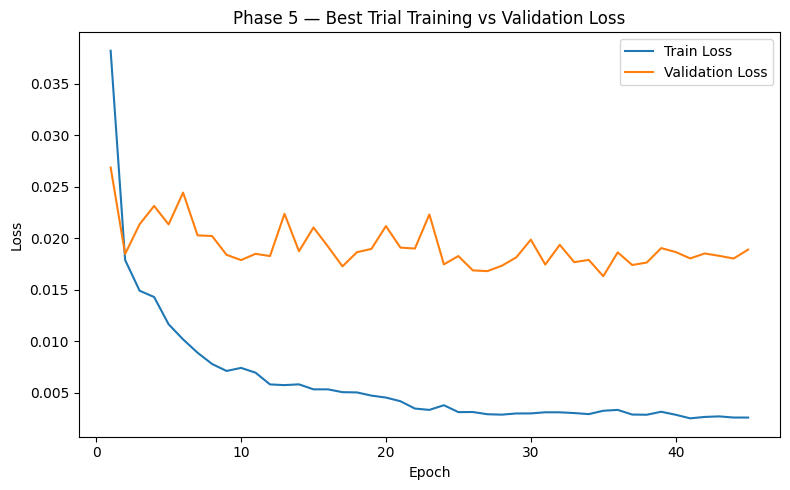

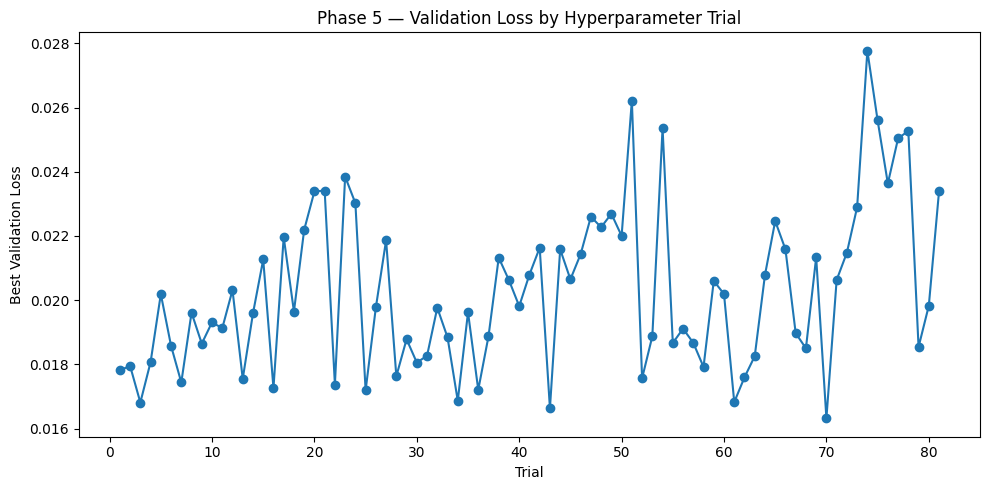

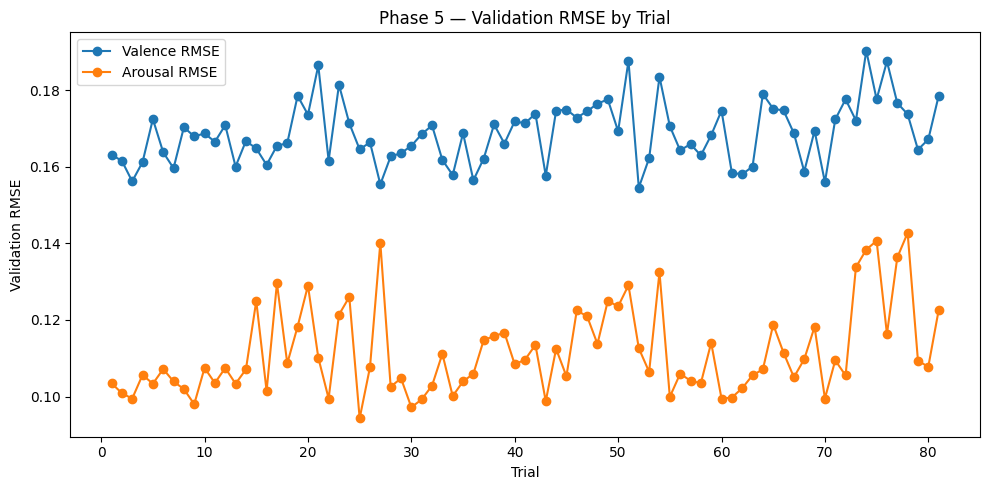

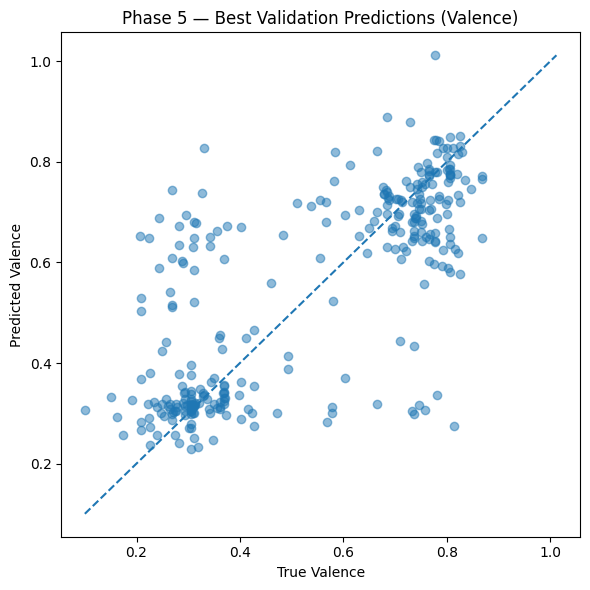

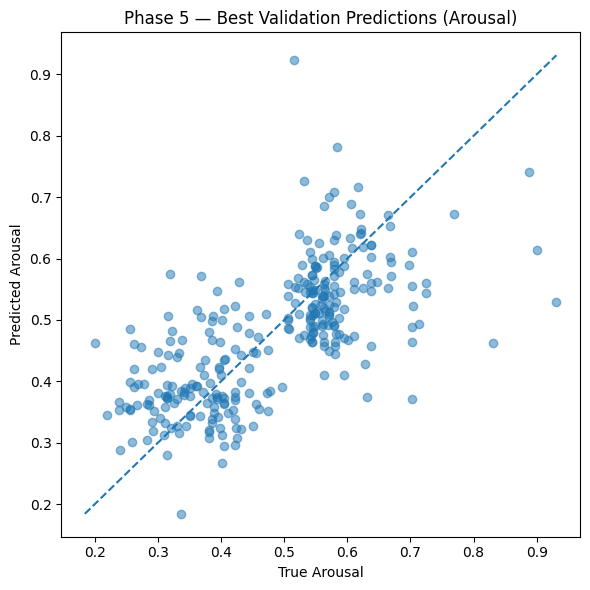


Phase 5 complete.
Best trial: 70
Artifacts saved in: /content/data/phase5_hyperparameter_tuning
Plots saved in: /content/data/phase5_hyperparameter_tuning/plots


In [ ]:

# -----------------------------
# 18. Report-ready plots
# -----------------------------
# Plot best training curve
plot_history(
    best_history_df,
    title="Phase 5 — Best Trial Training vs Validation Loss",
    filename="best_trial_loss_curve.png"
)

# Plot validation loss across all trials
plot_trial_validation_losses(
    pd.DataFrame(all_results),
    filename="validation_loss_by_trial.png"
)

# Plot validation RMSE across all trials
plot_trial_rmse(
    pd.DataFrame(all_results),
    filename="validation_rmse_by_trial.png"
)

# Scatter plot: best validation valence predictions
plt.figure(figsize=(6, 6))
plt.scatter(best_val_true[:, 0], best_val_preds[:, 0], alpha=0.5)
min_val = min(best_val_true[:, 0].min(), best_val_preds[:, 0].min())
max_val = max(best_val_true[:, 0].max(), best_val_preds[:, 0].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True Valence")
plt.ylabel("Predicted Valence")
plt.title("Phase 5 — Best Validation Predictions (Valence)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_valence_predicted_vs_true.png", dpi=300, bbox_inches="tight")
plt.show()

# Scatter plot: best validation arousal predictions
plt.figure(figsize=(6, 6))
plt.scatter(best_val_true[:, 1], best_val_preds[:, 1], alpha=0.5)
min_val = min(best_val_true[:, 1].min(), best_val_preds[:, 1].min())
max_val = max(best_val_true[:, 1].max(), best_val_preds[:, 1].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True Arousal")
plt.ylabel("Predicted Arousal")
plt.title("Phase 5 — Best Validation Predictions (Arousal)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "best_arousal_predicted_vs_true.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 19. Final summary
# -----------------------------
# Final confirmation of outputs
print("\nPhase 5 complete.")
print("Best trial:", best_trial_id)
print("Artifacts saved in:", PHASE5_DIR)
print("Plots saved in:", PLOTS_DIR)

## Phase 6 — Final Tuned Multimodal Model


I trained the final multimodal model using the best hyperparameters and evaluated its performance on the test set.


In [ ]:
# ============================================================
# PHASE 6 — FINAL TUNED MULTIMODAL MODEL
# Goal:
#   Train the final optimized multimodal valence-arousal model
#   using the best hyperparameters from Phase 5, then generate
#   official predictions on the test set.
#
# This phase:
#   1) loads Phase 2 embeddings
#   2) loads Phase 1 train / validation / test splits
#   3) loads best hyperparameters from Phase 5
#   4) combines train + validation for final training
#   5) standardizes embeddings using train+val statistics only
#   6) retrains the final tuned multimodal model
#   7) evaluates on the held-out test set
#   8) saves final model, metrics, predictions, and plots
#
# Inputs:
#   - phase2_metadata.parquet
#   - audio_embeddings.npy
#   - lyrics_embeddings.npy
#   - train.csv / val.csv / test.csv
#   - best_hyperparameters.json (from Phase 5)
#
# Outputs:
#   - final_tuned_multimodal_model.pt
#   - training_history.csv
#   - final_test_metrics.csv
#   - test_predictions (.npy and .csv)
#   - used_hyperparameters.json
#   - plots (training curve, predictions, RMSE)
# ============================================================

# -----------------------------
# 1. Install required packages
# -----------------------------
# Install PyTorch and parquet support
!pip -q install torch pyarrow

# -----------------------------
# 2. Imports
# -----------------------------

import copy
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 3. Paths
# -----------------------------
# Define directories for inputs and outputs
DATA_DIR = Path("/content/data")
PHASE1_DIR = DATA_DIR / "splits"
PHASE2_DIR = DATA_DIR / "phase2_features"
PHASE5_DIR = DATA_DIR / "phase5_hyperparameter_tuning"
PHASE6_DIR = DATA_DIR / "phase6_final_tuned_multimodal_model"
PLOTS_DIR = PHASE6_DIR / "plots"

# Create output folders
PHASE6_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 4. Reproducibility and device
# -----------------------------
# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:


# -----------------------------
# 5. Load Phase 5 best hyperparameters
# -----------------------------
# Load best configuration from Phase 5 tuning
with open(PHASE5_DIR / "best_hyperparameters.json", "r") as f:
    best_config = json.load(f)

print("Best hyperparameters from Phase 5:")
print(best_config)

# Extract hyperparameters
HIDDEN_SIZE = int(best_config["hidden_size"])
DROPOUT = float(best_config["dropout"])
LEARNING_RATE = float(best_config["learning_rate"])
BATCH_SIZE = int(best_config["batch_size"])
WEIGHT_DECAY = float(best_config.get("weight_decay", 1e-5))
EPOCHS = int(best_config.get("max_epochs", 80))
PATIENCE = int(best_config.get("patience", 10))

# -----------------------------
# 6. Load Phase 2 features
# -----------------------------
# Load metadata and embeddings
phase2_df_full = pd.read_parquet(PHASE2_DIR / "phase2_metadata.parquet").reset_index(drop=True)
audio_embeddings_full = np.load(PHASE2_DIR / "audio_embeddings.npy")
lyrics_embeddings_full = np.load(PHASE2_DIR / "lyrics_embeddings.npy")

# Verify alignment
print("phase2_df_full shape:", phase2_df_full.shape)
print("audio_embeddings_full shape:", audio_embeddings_full.shape)
print("lyrics_embeddings_full shape:", lyrics_embeddings_full.shape)

assert len(phase2_df_full) == len(audio_embeddings_full)
assert len(phase2_df_full) == len(lyrics_embeddings_full)

# -----------------------------
# 7. Load Phase 1 splits
# -----------------------------
# Load train/validation/test splits
train_df = pd.read_csv(PHASE1_DIR / "train.csv")
val_df = pd.read_csv(PHASE1_DIR / "val.csv")
test_df = pd.read_csv(PHASE1_DIR / "test.csv")

print("train_df shape:", train_df.shape)
print("val_df shape:", val_df.shape)
print("test_df shape:", test_df.shape)

# -----------------------------
# 8. Attach split labels
# -----------------------------
# Map each song_id to its split
split_map = {}

for sid in train_df["song_id"].tolist():
    split_map[sid] = "train"

for sid in val_df["song_id"].tolist():
    split_map[sid] = "val"

for sid in test_df["song_id"].tolist():
    split_map[sid] = "test"

phase2_df = phase2_df_full.copy()
phase2_df["split"] = phase2_df["song_id"].map(split_map)
phase2_df = phase2_df.dropna(subset=["split"]).reset_index(drop=True)

print("\nSplit counts inside phase2_df:")
print(phase2_df["split"].value_counts())

# -----------------------------
# 9. Realign embeddings to filtered metadata
# -----------------------------
# Ensure embeddings match filtered dataset
source_ids = phase2_df_full["song_id"].tolist()
source_index = {sid: i for i, sid in enumerate(source_ids)}

ordered_ids = phase2_df["song_id"].tolist()
ordered_indices = [source_index[sid] for sid in ordered_ids]

audio_embeddings = audio_embeddings_full[ordered_indices]
lyrics_embeddings = lyrics_embeddings_full[ordered_indices]

print("\nAfter realignment:")
print("phase2_df shape:", phase2_df.shape)
print("audio_embeddings shape:", audio_embeddings.shape)
print("lyrics_embeddings shape:", lyrics_embeddings.shape)

assert len(phase2_df) == len(audio_embeddings)
assert len(phase2_df) == len(lyrics_embeddings)





Best hyperparameters from Phase 5:
{'hidden_size': 512, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'weight_decay': 1e-05, 'max_epochs': 80, 'patience': 10}
phase2_df_full shape: (2000, 5)
audio_embeddings_full shape: (2000, 768)
lyrics_embeddings_full shape: (2000, 384)
train_df shape: (1400, 5)
val_df shape: (300, 5)
test_df shape: (300, 5)

Split counts inside phase2_df:
split
train    1400
test      300
val       300
Name: count, dtype: int64

After realignment:
phase2_df shape: (2000, 6)
audio_embeddings shape: (2000, 768)
lyrics_embeddings shape: (2000, 384)


In [ ]:
# -----------------------------
# 10. Build final train / test arrays
# -----------------------------
# Combine train + validation for final training
final_train_mask = phase2_df["split"].isin(["train", "val"])
test_mask = phase2_df["split"] == "test"

# Split features
X_audio_train = audio_embeddings[final_train_mask.values]
X_audio_test = audio_embeddings[test_mask.values]

X_lyrics_train = lyrics_embeddings[final_train_mask.values]
X_lyrics_test = lyrics_embeddings[test_mask.values]

# Targets
y_train = phase2_df.loc[final_train_mask, ["valence", "arousal"]].values.astype(np.float32)
y_test = phase2_df.loc[test_mask, ["valence", "arousal"]].values.astype(np.float32)

song_ids_train = phase2_df.loc[final_train_mask, "song_id"].values
song_ids_test = phase2_df.loc[test_mask, "song_id"].values

print("\nFinal training shapes:")
print("Audio:", X_audio_train.shape, "| Lyrics:", X_lyrics_train.shape, "| y:", y_train.shape)

print("\nTest shapes:")
print("Audio:", X_audio_test.shape, "| Lyrics:", X_lyrics_test.shape, "| y:", y_test.shape)

# -----------------------------
# 11. Standardize embeddings
# -----------------------------
# Normalize using train+val statistics
audio_mean = X_audio_train.mean(axis=0, keepdims=True)
audio_std = X_audio_train.std(axis=0, keepdims=True) + 1e-8

lyrics_mean = X_lyrics_train.mean(axis=0, keepdims=True)
lyrics_std = X_lyrics_train.std(axis=0, keepdims=True) + 1e-8

X_audio_train = (X_audio_train - audio_mean) / audio_std
X_audio_test = (X_audio_test - audio_mean) / audio_std

X_lyrics_train = (X_lyrics_train - lyrics_mean) / lyrics_std
X_lyrics_test = (X_lyrics_test - lyrics_mean) / lyrics_std

# Save normalization parameters
np.save(PHASE6_DIR / "audio_mean.npy", audio_mean)
np.save(PHASE6_DIR / "audio_std.npy", audio_std)
np.save(PHASE6_DIR / "lyrics_mean.npy", lyrics_mean)
np.save(PHASE6_DIR / "lyrics_std.npy", lyrics_std)


Final training shapes:
Audio: (1700, 768) | Lyrics: (1700, 384) | y: (1700, 2)

Test shapes:
Audio: (300, 768) | Lyrics: (300, 384) | y: (300, 2)


In [ ]:
# -----------------------------
# 12. Dataset and dataloaders
# -----------------------------
# PyTorch dataset for multimodal inputs
class MultimodalEmotionDataset(Dataset):
    def __init__(self, audio_features, lyrics_features, targets):
        self.audio_features = torch.tensor(audio_features, dtype=torch.float32)
        self.lyrics_features = torch.tensor(lyrics_features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            self.audio_features[idx],
            self.lyrics_features[idx],
            self.targets[idx]
        )

# Create datasets for final training and test evaluation
train_dataset = MultimodalEmotionDataset(X_audio_train, X_lyrics_train, y_train)
test_dataset = MultimodalEmotionDataset(X_audio_test, X_lyrics_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 13. Model definition
# -----------------------------
# Final multimodal regressor using the best tuned hyperparameters
class FinalTunedMultimodalRegressor(nn.Module):
    def __init__(self, audio_dim, lyrics_dim, hidden_size=256, dropout=0.30):
        super().__init__()

        # Hidden sizes for modality branches and fusion layers
        branch_hidden_1 = hidden_size
        branch_hidden_2 = max(hidden_size // 2, 32)
        fusion_hidden_1 = hidden_size
        fusion_hidden_2 = max(hidden_size // 4, 16)

        # Audio branch
        self.audio_branch = nn.Sequential(
            nn.Linear(audio_dim, branch_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_hidden_1, branch_hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Lyrics branch
        self.lyrics_branch = nn.Sequential(
            nn.Linear(lyrics_dim, branch_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(branch_hidden_1, branch_hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Fusion head combines both branches and predicts valence/arousal
        self.fusion_head = nn.Sequential(
            nn.Linear(branch_hidden_2 * 2, fusion_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_1, fusion_hidden_2),
            nn.ReLU(),
            nn.Linear(fusion_hidden_2, 2)
        )

    def forward(self, audio_x, lyrics_x):
        audio_repr = self.audio_branch(audio_x)
        lyrics_repr = self.lyrics_branch(lyrics_x)
        fused = torch.cat([audio_repr, lyrics_repr], dim=1)
        return self.fusion_head(fused)

# Initialize final model with tuned hyperparameters
model = FinalTunedMultimodalRegressor(
    audio_dim=X_audio_train.shape[1],
    lyrics_dim=X_lyrics_train.shape[1],
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT
).to(device)

print(model)

# -----------------------------
# 14. Helper functions
# -----------------------------
# Reset random seeds before final training
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Run inference on a dataloader
def predict_model(model, dataloader, device):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for batch_audio, batch_lyrics, batch_targets in dataloader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)

            preds = model(batch_audio, batch_lyrics).cpu().numpy()
            preds_list.append(preds)
            targets_list.append(batch_targets.numpy())

    return np.vstack(preds_list), np.vstack(targets_list)

# Compute regression metrics for one target
def regression_metrics(y_true, y_pred, target_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "target": target_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

# Ensure final training is reproducible
set_seed(SEED)

FinalTunedMultimodalRegressor(
  (audio_branch): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (lyrics_branch): Sequential(
    (0): Linear(in_features=384, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (fusion_head): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
# -----------------------------
# 15. Training setup
# -----------------------------
# Loss function
criterion = nn.MSELoss()

# Optimizer uses tuned learning rate and weight decay
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Store training loss for plotting
history = {
    "epoch": [],
    "train_loss": []
}

# Track best training loss and early stopping
best_train_loss = float("inf")
best_state = None
best_epoch = 0
epochs_without_improvement = 0

# -----------------------------
# 16. Final training loop
# -----------------------------
# Train on combined train+validation data
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for batch_audio, batch_lyrics, batch_targets in train_loader:
        batch_audio = batch_audio.to(device)
        batch_lyrics = batch_lyrics.to(device)
        batch_targets = batch_targets.to(device)

        # Standard training step
        optimizer.zero_grad()
        preds = model(batch_audio, batch_lyrics)
        loss = criterion(preds, batch_targets)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Average training loss for this epoch
    avg_train_loss = float(np.mean(train_losses))

    history["epoch"].append(epoch)
    history["train_loss"].append(avg_train_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.6f}")

    # Keep best model based on training loss
    if avg_train_loss < best_train_loss:
        best_train_loss = avg_train_loss
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping if training loss stops improving
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# -----------------------------
# 17. Load best final model
# -----------------------------
# Restore best-performing final model
model.load_state_dict(best_state)

# -----------------------------
# 18. Save model and training history
# -----------------------------
# Save training loss history
history_df = pd.DataFrame(history)
history_df.to_csv(PHASE6_DIR / "training_history.csv", index=False)

# Save final trained model weights
torch.save(model.state_dict(), PHASE6_DIR / "final_tuned_multimodal_model.pt")

# Save hyperparameters actually used in final training
with open(PHASE6_DIR / "used_hyperparameters.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("\nSaved:")
print("-", PHASE6_DIR / "training_history.csv")
print("-", PHASE6_DIR / "final_tuned_multimodal_model.pt")
print("-", PHASE6_DIR / "used_hyperparameters.json")

Epoch 001 | Train Loss: 0.048506
Epoch 002 | Train Loss: 0.022260
Epoch 003 | Train Loss: 0.016778
Epoch 004 | Train Loss: 0.015746
Epoch 005 | Train Loss: 0.014030
Epoch 006 | Train Loss: 0.012917
Epoch 007 | Train Loss: 0.011082
Epoch 008 | Train Loss: 0.010041
Epoch 009 | Train Loss: 0.010691
Epoch 010 | Train Loss: 0.009041
Epoch 011 | Train Loss: 0.008840
Epoch 012 | Train Loss: 0.008644
Epoch 013 | Train Loss: 0.008835
Epoch 014 | Train Loss: 0.007653
Epoch 015 | Train Loss: 0.006660
Epoch 016 | Train Loss: 0.007350
Epoch 017 | Train Loss: 0.006251
Epoch 018 | Train Loss: 0.006994
Epoch 019 | Train Loss: 0.006123
Epoch 020 | Train Loss: 0.005491
Epoch 021 | Train Loss: 0.005354
Epoch 022 | Train Loss: 0.005924
Epoch 023 | Train Loss: 0.005904
Epoch 024 | Train Loss: 0.004963
Epoch 025 | Train Loss: 0.004477
Epoch 026 | Train Loss: 0.004441
Epoch 027 | Train Loss: 0.004267
Epoch 028 | Train Loss: 0.003869
Epoch 029 | Train Loss: 0.004079
Epoch 030 | Train Loss: 0.003680
Epoch 031 


Final test results:


,target,MSE,RMSE,MAE,R2
0,valence_test,0.028688,0.169374,0.116482,0.461162
1,arousal_test,0.008874,0.094201,0.069297,0.541238



Saved prediction files.


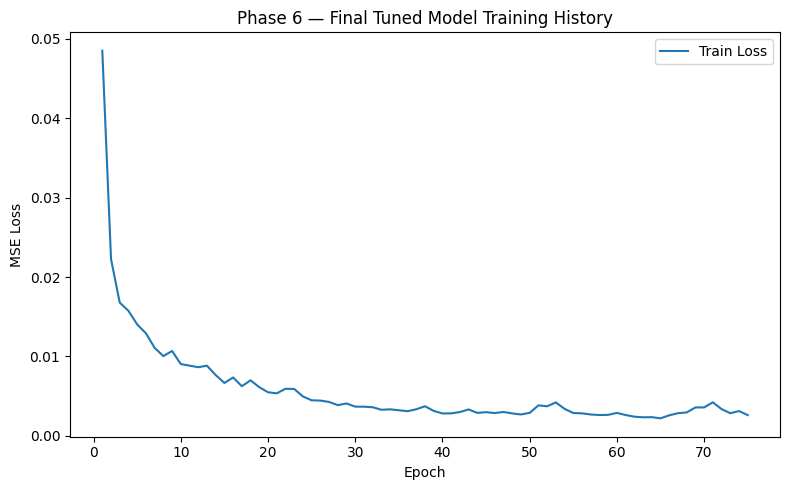

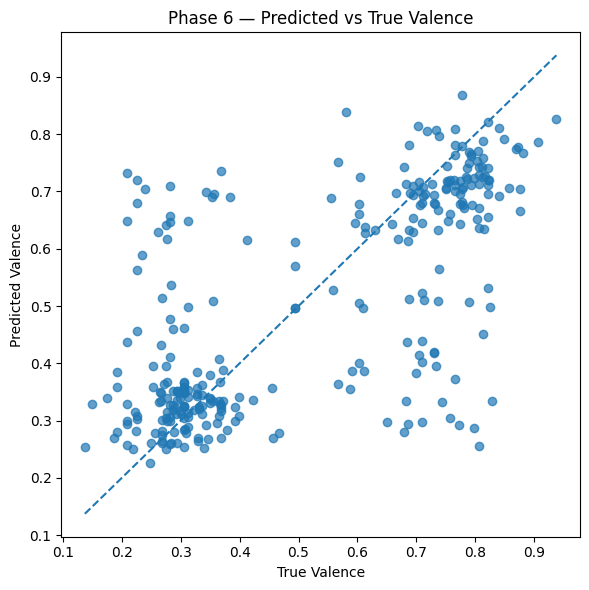

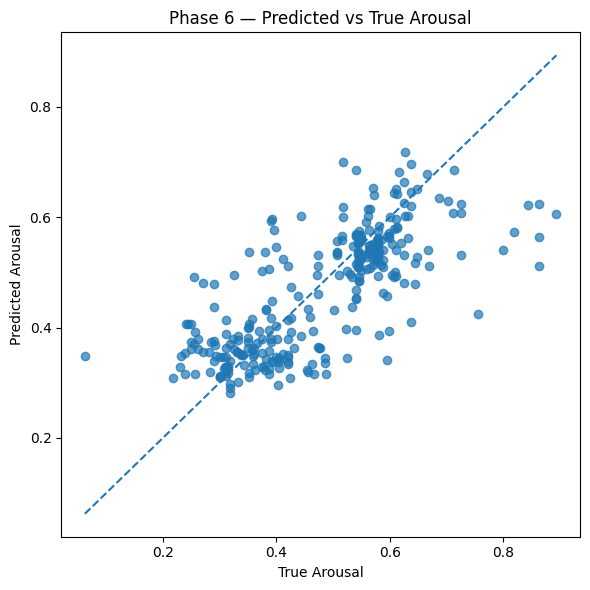

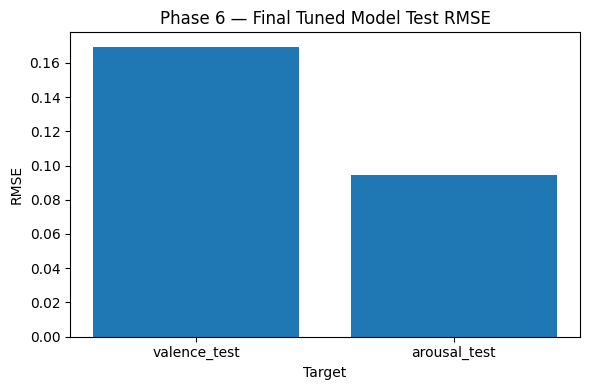


Phase 6 complete.
Best epoch used: 65
Artifacts saved in: /content/data/phase6_final_tuned_multimodal_model
Plots saved in: /content/data/phase6_final_tuned_multimodal_model/plots


In [ ]:

# -----------------------------
# 19. Evaluate on test set
# -----------------------------
# Generate test predictions
test_preds, test_true = predict_model(model, test_loader, device)

# Compute final test metrics
results = []
results.append(regression_metrics(test_true[:, 0], test_preds[:, 0], "valence_test"))
results.append(regression_metrics(test_true[:, 1], test_preds[:, 1], "arousal_test"))

results_df = pd.DataFrame(results)
results_df.to_csv(PHASE6_DIR / "final_test_metrics.csv", index=False)

print("\nFinal test results:")
display(results_df)

# -----------------------------
# 20. Save predictions
# -----------------------------
# Save raw arrays
np.save(PHASE6_DIR / "test_predictions.npy", test_preds)
np.save(PHASE6_DIR / "test_true.npy", test_true)

# Save predictions in CSV format for inspection and later phases
predictions_df = pd.DataFrame({
    "song_id": song_ids_test,
    "true_valence": test_true[:, 0],
    "pred_valence": test_preds[:, 0],
    "true_arousal": test_true[:, 1],
    "pred_arousal": test_preds[:, 1],
})
predictions_df.to_csv(PHASE6_DIR / "test_predictions.csv", index=False)

print("\nSaved prediction files.")

# -----------------------------
# 21. Report-ready plots
# -----------------------------
# Plot training loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Phase 6 — Final Tuned Model Training History")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_history.png", dpi=300)
plt.show()

# Plot predicted vs true valence
plt.figure(figsize=(6, 6))
plt.scatter(test_true[:, 0], test_preds[:, 0], alpha=0.7)
min_v = min(test_true[:, 0].min(), test_preds[:, 0].min())
max_v = max(test_true[:, 0].max(), test_preds[:, 0].max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("True Valence")
plt.ylabel("Predicted Valence")
plt.title("Phase 6 — Predicted vs True Valence")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valence_predicted_vs_true.png", dpi=300)
plt.show()

# Plot predicted vs true arousal
plt.figure(figsize=(6, 6))
plt.scatter(test_true[:, 1], test_preds[:, 1], alpha=0.7)
min_a = min(test_true[:, 1].min(), test_preds[:, 1].min())
max_a = max(test_true[:, 1].max(), test_preds[:, 1].max())
plt.plot([min_a, max_a], [min_a, max_a], linestyle="--")
plt.xlabel("True Arousal")
plt.ylabel("Predicted Arousal")
plt.title("Phase 6 — Predicted vs True Arousal")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "arousal_predicted_vs_true.png", dpi=300)
plt.show()

# Plot RMSE for final test results
plt.figure(figsize=(6, 4))
plt.bar(results_df["target"], results_df["RMSE"])
plt.xlabel("Target")
plt.ylabel("RMSE")
plt.title("Phase 6 — Final Tuned Model Test RMSE")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "final_test_rmse.png", dpi=300)
plt.show()

# -----------------------------
# 22. Final summary
# -----------------------------
# Final confirmation message
print("\nPhase 6 complete.")
print("Best epoch used:", best_epoch)
print("Artifacts saved in:", PHASE6_DIR)
print("Plots saved in:", PLOTS_DIR)

## Phase 7 — VA to Emotion Mapping

I converted the predicted valence–arousal values into multiple emotion labels using a rule-based mapping approach.


In [ ]:
# ============================================================
# PHASE 7 — VA TO EMOTION MAPPING
# Goal:
#   Convert continuous valence-arousal predictions into
#   interpretable multi-label emotion outputs.
#
# This version:
#   1) loads Phase 6 test predictions
#   2) rescales VA from [0, 1] to [-1, 1]
#   3) maps predicted VA to multi-label emotions
#   4) evaluates predicted labels against true labels
#   5) saves outputs and report-ready plots
#
# Inputs:
#   - test_predictions.csv (from Phase 6)
#
# Outputs:
#   - emotion_predictions.csv
#   - emotion_mapping_metrics.csv
#   - emotion_classification_report.csv
#   - primary_emotion_confusion_table.csv
#   - emotion_label_set.csv
#   - plots (distributions, VA maps, agreement, mapping diagram)
# ============================================================

# -----------------------------
# 1. Imports
# -----------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Multi-label evaluation tools
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    hamming_loss,
    classification_report
)

# -----------------------------
# 2. Paths
# -----------------------------
# Define input/output directories
DATA_DIR = Path("/content/data")
PHASE6_DIR = DATA_DIR / "phase6_final_tuned_multimodal_model"
PHASE7_DIR = DATA_DIR / "phase7_emotion_mapping"
PLOTS_DIR = PHASE7_DIR / "plots"

# Create output folders
PHASE7_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 3. Load Phase 6 predictions
# -----------------------------
# Load test predictions produced by the final model
predictions_df = pd.read_csv(PHASE6_DIR / "test_predictions.csv")

print("Loaded test predictions:", predictions_df.shape)
display(predictions_df.head())

# -----------------------------
# 4. Rescale VA values
# -----------------------------
# Convert [0,1] to [-1,1] for easier quadrant interpretation
def rescale_to_signed(x):
    return 2.0 * x - 1.0

# Apply transformation to true and predicted values
predictions_df["true_valence_signed"] = rescale_to_signed(predictions_df["true_valence"])
predictions_df["pred_valence_signed"] = rescale_to_signed(predictions_df["pred_valence"])
predictions_df["true_arousal_signed"] = rescale_to_signed(predictions_df["true_arousal"])
predictions_df["pred_arousal_signed"] = rescale_to_signed(predictions_df["pred_arousal"])

# Display ranges for sanity check
print("\nSigned VA ranges after rescaling:")
print("True valence:", predictions_df["true_valence_signed"].min(), "to", predictions_df["true_valence_signed"].max())
print("Pred valence:", predictions_df["pred_valence_signed"].min(), "to", predictions_df["pred_valence_signed"].max())
print("True arousal:", predictions_df["true_arousal_signed"].min(), "to", predictions_df["true_arousal_signed"].max())
print("Pred arousal:", predictions_df["pred_arousal_signed"].min(), "to", predictions_df["pred_arousal_signed"].max())


Loaded test predictions: (300, 5)


,song_id,true_valence,pred_valence,true_arousal,pred_arousal
0,A003,0.22500,0.282698,0.25000,0.361679
1,A043,0.78125,0.670999,0.75625,0.424363
2,A061-66,0.21875,0.251042,0.28125,0.355562
3,A064-116,0.90625,0.785655,0.89375,0.606103
4,A090-94,0.15000,0.328830,0.86250,0.510937



Signed VA ranges after rescaling:
True valence: -0.725 to 0.875
Pred valence: -0.54798996 to 0.7350254
True arousal: -0.875 to 0.7875000000000001
Pred arousal: -0.43779206000000004 to 0.43843352


In [ ]:

# -----------------------------
# 5. Helper functions
# -----------------------------
# Clip values to valid range [-1,1]
def clip_va(value):
    return float(np.clip(value, -1.0, 1.0))


def map_va_to_emotions(valence, arousal, threshold=0.15):
    """
    Map a valence-arousal pair to one or more emotion labels.
    """
    v = clip_va(valence)
    a = clip_va(arousal)

    emotions = []

    # Q1: high valence, high arousal
    if v >= threshold and a >= threshold:
        emotions.extend(["happy", "excited", "joyful", "energetic"])
        if v > 0.6 and a > 0.6:
            emotions.append("euphoric")

    # Q2: low valence, high arousal
    elif v <= -threshold and a >= threshold:
        emotions.extend(["angry", "tense", "anxious"])
        if v < -0.5:
            emotions.append("frustrated")
        if a > 0.6:
            emotions.append("aggressive")

    # Q3: low valence, low arousal
    elif v <= -threshold and a <= -threshold:
        emotions.extend(["sad", "melancholic", "depressed"])
        if v < -0.6:
            emotions.append("lonely")
        if a < -0.6:
            emotions.append("tired")

    # Q4: high valence, low arousal
    elif v >= threshold and a <= -threshold:
        emotions.extend(["calm", "relaxed", "peaceful"])
        if v > 0.5:
            emotions.append("content")
        if a < -0.6:
            emotions.append("serene")

    # Boundary / neutral regions
    else:
        if abs(v) < threshold and a >= threshold:
            emotions.extend(["energetic", "tense", "emotional"])

        elif abs(v) < threshold and a <= -threshold:
            emotions.extend(["calm", "melancholic", "introspective"])

        elif v >= threshold and abs(a) < threshold:
            emotions.extend(["content", "happy", "peaceful"])

        elif v <= -threshold and abs(a) < threshold:
            emotions.extend(["sad", "melancholic", "introspective"])

        else:
            emotions.extend(["neutral", "mixed"])

    # Remove duplicates while preserving order
    return list(dict.fromkeys(emotions))


# Extract primary emotion (first label)
def get_primary_emotion(emotion_list):
    return emotion_list[0] if emotion_list else "neutral"


# Count frequency of each label
def count_labels(series_of_lists):
    counts = {}
    for labels in series_of_lists:
        for label in labels:
            counts[label] = counts.get(label, 0) + 1
    return pd.Series(counts).sort_values(ascending=False)

In [ ]:

# -----------------------------
# 6. Create true and predicted labels
# -----------------------------
# Apply mapping to both ground truth and predictions
THRESHOLD = 0.15

predictions_df["true_labels"] = predictions_df.apply(
    lambda row: map_va_to_emotions(
        row["true_valence_signed"],
        row["true_arousal_signed"],
        threshold=THRESHOLD
    ),
    axis=1
)

predictions_df["pred_labels"] = predictions_df.apply(
    lambda row: map_va_to_emotions(
        row["pred_valence_signed"],
        row["pred_arousal_signed"],
        threshold=THRESHOLD
    ),
    axis=1
)

# Extract primary emotion for visualization
predictions_df["true_primary_emotion"] = predictions_df["true_labels"].apply(get_primary_emotion)
predictions_df["pred_primary_emotion"] = predictions_df["pred_labels"].apply(get_primary_emotion)

# Show examples
print("\nExample mapped labels:")
display(predictions_df.head(10))

# -----------------------------
# 7. Multi-label evaluation
# -----------------------------
# Convert label lists into binary matrix format
all_label_sets = list(predictions_df["true_labels"]) + list(predictions_df["pred_labels"])

mlb = MultiLabelBinarizer()
mlb.fit(all_label_sets)

y_true_multi = mlb.transform(predictions_df["true_labels"])
y_pred_multi = mlb.transform(predictions_df["pred_labels"])

# Compute evaluation metrics
metrics = {
    "micro_f1": f1_score(y_true_multi, y_pred_multi, average="micro", zero_division=0),
    "macro_f1": f1_score(y_true_multi, y_pred_multi, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true_multi, y_pred_multi, average="weighted", zero_division=0),
    "samples_f1": f1_score(y_true_multi, y_pred_multi, average="samples", zero_division=0),
    "exact_match_accuracy": accuracy_score(y_true_multi, y_pred_multi),
    "hamming_loss": hamming_loss(y_true_multi, y_pred_multi)
}

metrics_df = pd.DataFrame([metrics])

print("\nPhase 7 Multi-label Metrics:")
display(metrics_df)

# Detailed per-label report
report_dict = classification_report(
    y_true_multi,
    y_pred_multi,
    target_names=mlb.classes_,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()

print("\nPer-label classification report:")
display(report_df)

# -----------------------------
# 8. Save outputs
# -----------------------------
# Save predictions and evaluation results
predictions_df.to_csv(PHASE7_DIR / "emotion_predictions.csv", index=False)
metrics_df.to_csv(PHASE7_DIR / "emotion_mapping_metrics.csv", index=False)
report_df.to_csv(PHASE7_DIR / "emotion_classification_report.csv")

print("\nSaved Phase 7 outputs to:", PHASE7_DIR)



Example mapped labels:


,song_id,true_valence,pred_valence,true_arousal,pred_arousal,true_valence_signed,pred_valence_signed,true_arousal_signed,pred_arousal_signed,true_labels,pred_labels,true_primary_emotion,pred_primary_emotion
0,A003,0.22500,0.282698,0.25000,0.361679,-0.5500,-0.434605,-0.5000,-0.276642,"[sad, melancholic, depressed]","[sad, melancholic, depressed]",sad,sad
1,A043,0.78125,0.670999,0.75625,0.424363,0.5625,0.341999,0.5125,-0.151273,"[happy, excited, joyful, energetic]","[calm, relaxed, peaceful]",happy,calm
2,A061-66,0.21875,0.251042,0.28125,0.355562,-0.5625,-0.497917,-0.4375,-0.288877,"[sad, melancholic, depressed]","[sad, melancholic, depressed]",sad,sad
3,A064-116,0.90625,0.785655,0.89375,0.606103,0.8125,0.571310,0.7875,0.212205,"[happy, excited, joyful, energetic, euphoric]","[happy, excited, joyful, energetic]",happy,happy
4,A090-94,0.15000,0.328830,0.86250,0.510937,-0.7000,-0.342340,0.7250,0.021875,"[angry, tense, anxious, frustrated, aggressive]","[sad, melancholic, introspective]",angry,sad
5,A092-96,0.82500,0.497952,0.81875,0.573954,0.6500,-0.004096,0.6375,0.147909,"[happy, excited, joyful, energetic, euphoric]","[neutral, mixed]",happy,neutral
6,A094-110,0.88125,0.767513,0.86250,0.563398,0.7625,0.535026,0.7250,0.126795,"[happy, excited, joyful, energetic, euphoric]","[content, happy, peaceful]",happy,content
7,A117-76,0.18750,0.269103,0.23125,0.348624,-0.6250,-0.461793,-0.5375,-0.302752,"[sad, melancholic, depressed, lonely]","[sad, melancholic, depressed]",sad,sad
8,A143-72,0.30625,0.324507,0.21875,0.308510,-0.3875,-0.350985,-0.5625,-0.382980,"[sad, melancholic, depressed]","[sad, melancholic, depressed]",sad,sad
9,A160-149,0.93750,0.825751,0.86250,0.623219,0.8750,0.651502,0.7250,0.246438,"[happy, excited, joyful, energetic, euphoric]","[happy, excited, joyful, energetic]",happy,happy



Phase 7 Multi-label Metrics:


,micro_f1,macro_f1,weighted_f1,samples_f1,exact_match_accuracy,hamming_loss
0,0.587252,0.369288,0.568753,0.580794,0.463333,0.114493



Per-label classification report:


,precision,recall,f1-score,support
aggressive,0.000000,0.000000,0.000000,2.0
angry,0.250000,0.041667,0.071429,24.0
anxious,0.250000,0.041667,0.071429,24.0
calm,0.608696,0.626866,0.617647,67.0
content,0.405405,0.375000,0.389610,40.0
depressed,0.583333,0.593220,0.588235,59.0
emotional,1.000000,1.000000,1.000000,1.0
energetic,0.690476,0.517857,0.591837,56.0
euphoric,0.000000,0.000000,0.000000,5.0
excited,0.682927,0.509091,0.583333,55.0



Saved Phase 7 outputs to: /content/data/phase7_emotion_mapping


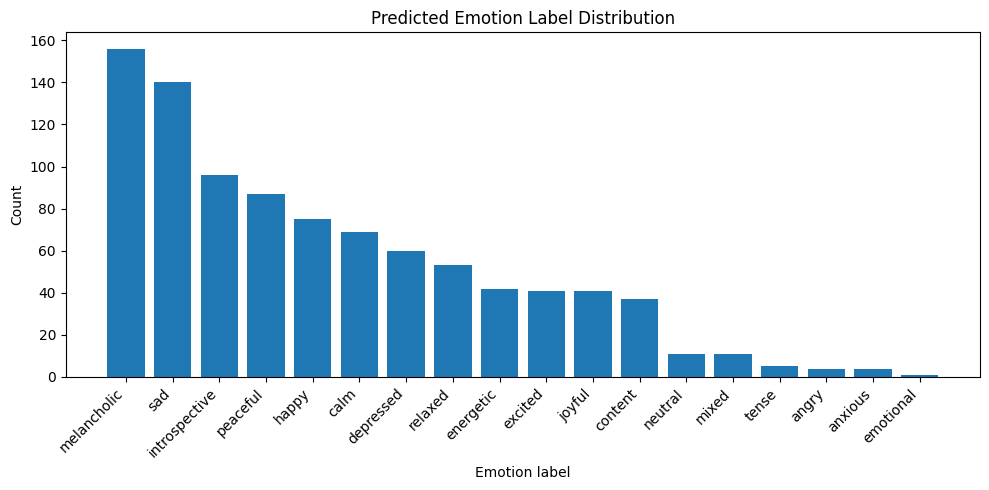

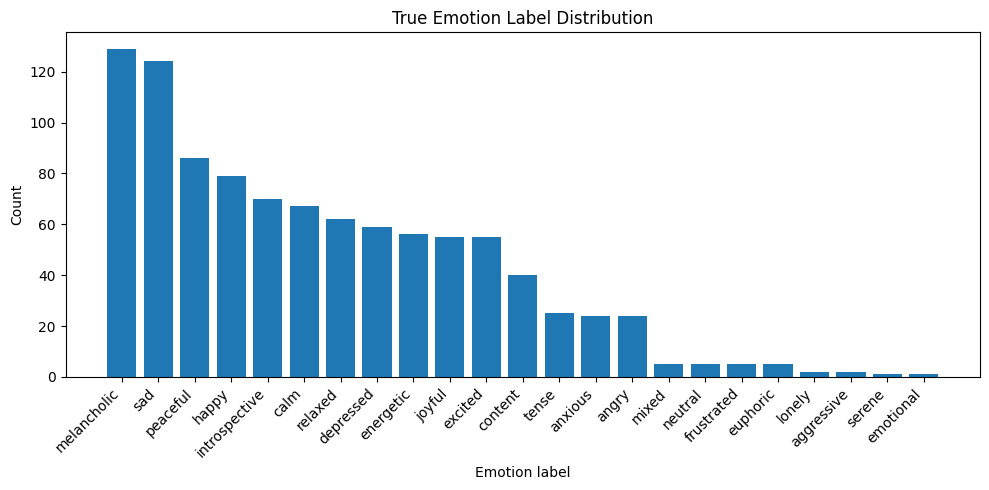

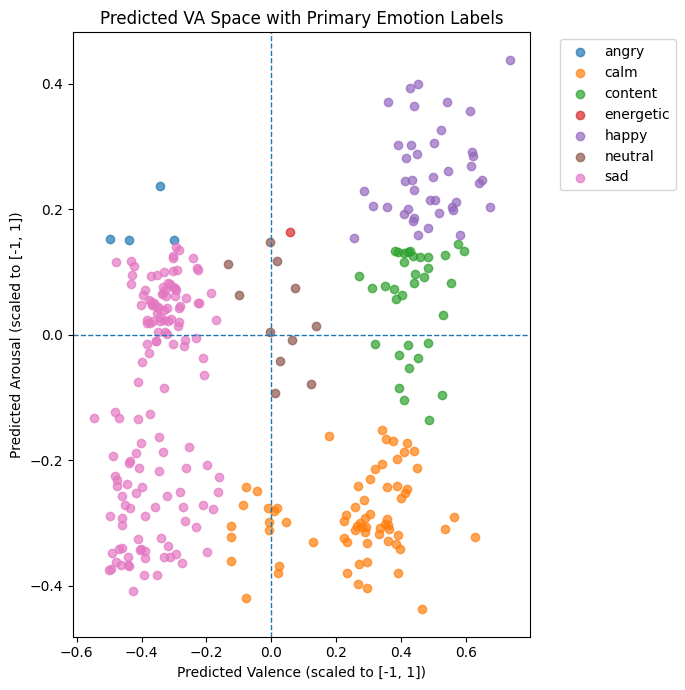

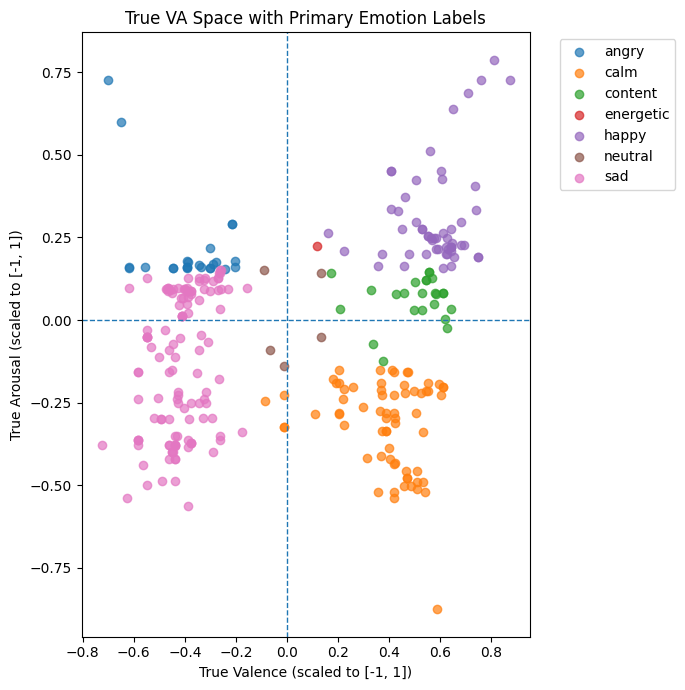

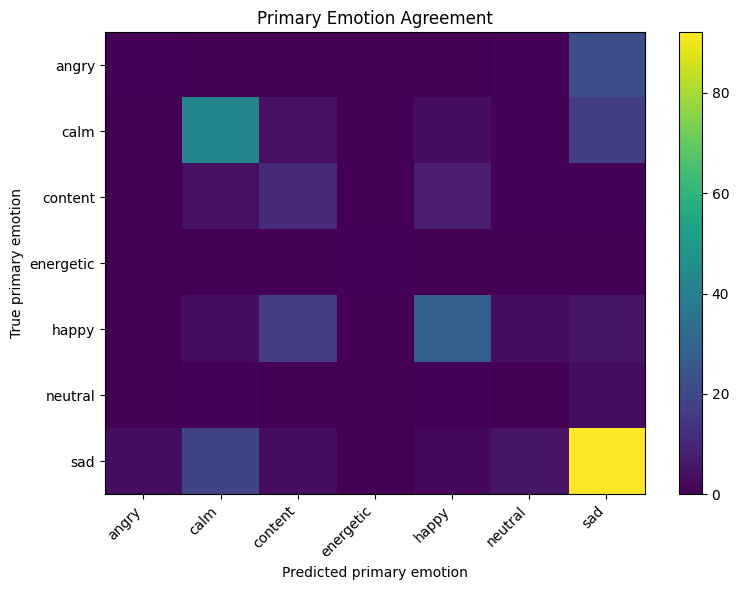

In [ ]:
# -----------------------------
# 9. Plot: predicted emotion distribution
# -----------------------------
# Count how often each predicted label appears
pred_label_counts = count_labels(predictions_df["pred_labels"])

# Bar chart of predicted emotion frequencies
plt.figure(figsize=(10, 5))
plt.bar(pred_label_counts.index, pred_label_counts.values)
plt.xlabel("Emotion label")
plt.ylabel("Count")
plt.title("Predicted Emotion Label Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "predicted_emotion_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 10. Plot: true emotion distribution
# -----------------------------
# Count how often each true label appears
true_label_counts = count_labels(predictions_df["true_labels"])

# Bar chart of true emotion frequencies
plt.figure(figsize=(10, 5))
plt.bar(true_label_counts.index, true_label_counts.values)
plt.xlabel("Emotion label")
plt.ylabel("Count")
plt.title("True Emotion Label Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "true_emotion_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 11. Plot: predicted VA with primary emotion
# -----------------------------
# Scatter plot of predicted valence-arousal values
# colored by predicted primary emotion
plt.figure(figsize=(7, 7))

for emotion in sorted(predictions_df["pred_primary_emotion"].unique()):
    subset = predictions_df[predictions_df["pred_primary_emotion"] == emotion]
    plt.scatter(
        subset["pred_valence_signed"],
        subset["pred_arousal_signed"],
        alpha=0.7,
        label=emotion
    )

# Add axis lines to show quadrant boundaries
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted Valence (scaled to [-1, 1])")
plt.ylabel("Predicted Arousal (scaled to [-1, 1])")
plt.title("Predicted VA Space with Primary Emotion Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "predicted_va_emotion_map.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 12. Plot: true VA with primary emotion
# -----------------------------
# Scatter plot of true valence-arousal values
# colored by true primary emotion
plt.figure(figsize=(7, 7))

for emotion in sorted(predictions_df["true_primary_emotion"].unique()):
    subset = predictions_df[predictions_df["true_primary_emotion"] == emotion]
    plt.scatter(
        subset["true_valence_signed"],
        subset["true_arousal_signed"],
        alpha=0.7,
        label=emotion
    )

# Add axis lines to show quadrant boundaries
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("True Valence (scaled to [-1, 1])")
plt.ylabel("True Arousal (scaled to [-1, 1])")
plt.title("True VA Space with Primary Emotion Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "true_va_emotion_map.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 13. Plot: primary emotion agreement
# -----------------------------
# Create confusion-style table between true and predicted primary emotions
agreement_df = pd.crosstab(
    predictions_df["true_primary_emotion"],
    predictions_df["pred_primary_emotion"]
)

# Save confusion table
agreement_df.to_csv(PHASE7_DIR / "primary_emotion_confusion_table.csv")

# Display as heatmap-style image
plt.figure(figsize=(8, 6))
plt.imshow(agreement_df.values, aspect="auto")
plt.xticks(range(len(agreement_df.columns)), agreement_df.columns, rotation=45, ha="right")
plt.yticks(range(len(agreement_df.index)), agreement_df.index)
plt.xlabel("Predicted primary emotion")
plt.ylabel("True primary emotion")
plt.title("Primary Emotion Agreement")
plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "primary_emotion_agreement.png", dpi=300, bbox_inches="tight")
plt.show()

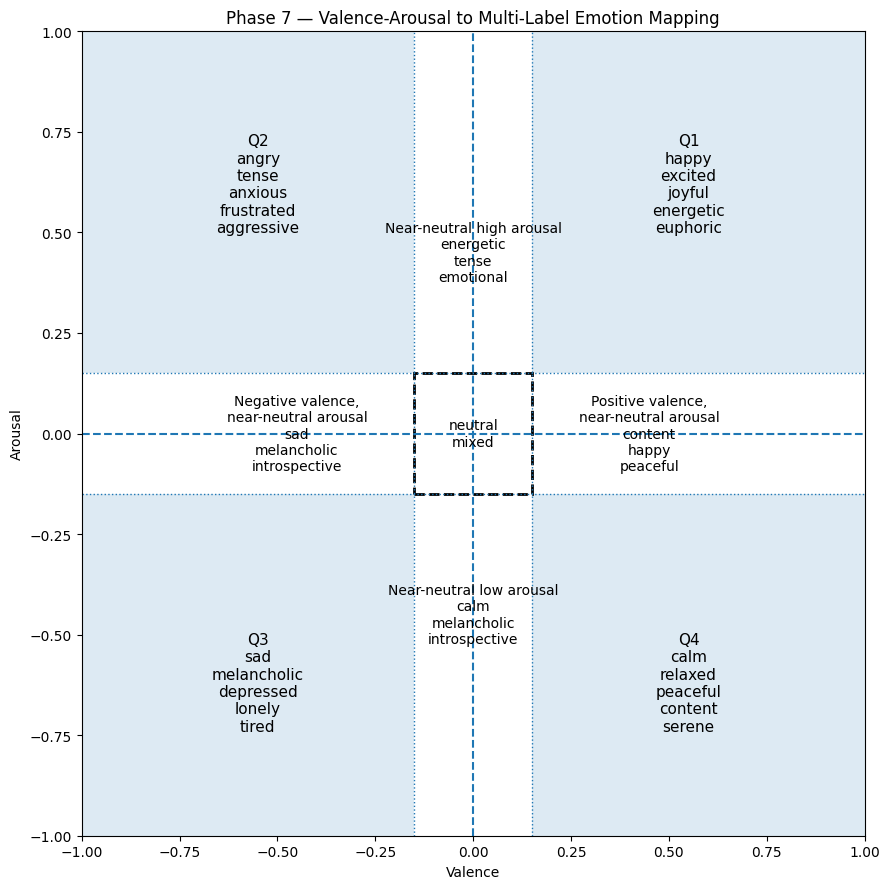


Emotion labels used:
['aggressive', 'angry', 'anxious', 'calm', 'content', 'depressed', 'emotional', 'energetic', 'euphoric', 'excited', 'frustrated', 'happy', 'introspective', 'joyful', 'lonely', 'melancholic', 'mixed', 'neutral', 'peaceful', 'relaxed', 'sad', 'serene', 'tense']

Phase 7 complete.
Artifacts saved in: /content/data/phase7_emotion_mapping
Plots saved in: /content/data/phase7_emotion_mapping/plots


In [ ]:

# -----------------------------
# 14. Create mapping diagram
# -----------------------------
# Create diagram that visually explains the rule-based VA to emotion mapping
fig, ax = plt.subplots(figsize=(9, 9))

# Shade the four main quadrants
ax.add_patch(Rectangle(( THRESHOLD,  THRESHOLD), 1-THRESHOLD, 1-THRESHOLD, alpha=0.15))
ax.add_patch(Rectangle((-1,         THRESHOLD), 1-THRESHOLD, 1-THRESHOLD, alpha=0.15))
ax.add_patch(Rectangle((-1,        -1),         1-THRESHOLD, 1-THRESHOLD, alpha=0.15))
ax.add_patch(Rectangle(( THRESHOLD, -1),        1-THRESHOLD, 1-THRESHOLD, alpha=0.15))

# Draw center neutral region
ax.add_patch(Rectangle(
    (-THRESHOLD, -THRESHOLD),
    2 * THRESHOLD,
    2 * THRESHOLD,
    fill=False,
    linestyle="--",
    linewidth=2
))

# Add main axes and threshold boundaries
ax.axhline(0, linestyle="--", linewidth=1.5)
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.axhline(THRESHOLD, linestyle=":", linewidth=1)
ax.axhline(-THRESHOLD, linestyle=":", linewidth=1)
ax.axvline(THRESHOLD, linestyle=":", linewidth=1)
ax.axvline(-THRESHOLD, linestyle=":", linewidth=1)

# Label Q1 emotions
ax.text(
    0.55, 0.62,
    "Q1\nhappy\nexcited\njoyful\nenergetic\neuphoric",
    ha="center", va="center", fontsize=11
)

# Label Q2 emotions
ax.text(
    -0.55, 0.62,
    "Q2\nangry\ntense\nanxious\nfrustrated\naggressive",
    ha="center", va="center", fontsize=11
)

# Label Q3 emotions
ax.text(
    -0.55, -0.62,
    "Q3\nsad\nmelancholic\ndepressed\nlonely\ntired",
    ha="center", va="center", fontsize=11
)

# Label Q4 emotions
ax.text(
    0.55, -0.62,
    "Q4\ncalm\nrelaxed\npeaceful\ncontent\nserene",
    ha="center", va="center", fontsize=11
)

# Label near-neutral high-arousal region
ax.text(
    0.0, 0.45,
    "Near-neutral high arousal\nenergetic\ntense\nemotional",
    ha="center", va="center", fontsize=10
)

# Label near-neutral low-arousal region
ax.text(
    0.0, -0.45,
    "Near-neutral low arousal\ncalm\nmelancholic\nintrospective",
    ha="center", va="center", fontsize=10
)

# Label positive-valence / neutral-arousal region
ax.text(
    0.45, 0.0,
    "Positive valence,\nnear-neutral arousal\ncontent\nhappy\npeaceful",
    ha="center", va="center", fontsize=10
)

# Label negative-valence / neutral-arousal region
ax.text(
    -0.45, 0.0,
    "Negative valence,\nnear-neutral arousal\nsad\nmelancholic\nintrospective",
    ha="center", va="center", fontsize=10
)

# Label center region
ax.text(
    0.0, 0.0,
    "neutral\nmixed",
    ha="center", va="center", fontsize=10
)

# Final axis formatting
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel("Valence")
ax.set_ylabel("Arousal")
ax.set_title("Phase 7 — Valence-Arousal to Multi-Label Emotion Mapping")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "va_emotion_mapping_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 15. Save label vocabulary
# -----------------------------
# Save the final set of emotion labels used in evaluation
labels_df = pd.DataFrame({"emotion_label": mlb.classes_})
labels_df.to_csv(PHASE7_DIR / "emotion_label_set.csv", index=False)

print("\nEmotion labels used:")
print(list(mlb.classes_))

# -----------------------------
# 16. Final summary
# -----------------------------
# Final confirmation of saved artifacts
print("\nPhase 7 complete.")
print("Artifacts saved in:", PHASE7_DIR)
print("Plots saved in:", PLOTS_DIR)

## Phase 8 — Direct Mood Prediction

I trained a model to directly predict mood labels from audio and lyrics using the dataset’s annotated mood information.

In [ ]:
# ============================================================
# PHASE 8 — DIRECT MOOD PREDICTION
# Goal:
#   Predict real human-annotated mood tags directly from
#   audio + lyrics using MERGE metadata:
#     - MoodsAll
#     - MoodsAllWeights
#
# This phase:
#   1) loads Phase 2 embeddings
#   2) reloads MERGE metadata with mood annotations
#   3) selects the top-K most frequent moods
#   4) builds weighted multi-label targets
#   5) trains a multimodal multi-label classifier
#   6) evaluates direct mood prediction
#   7) saves outputs and report-ready plots
#
# Inputs:
#   - phase2_metadata.parquet
#   - audio_embeddings.npy
#   - lyrics_embeddings.npy
#   - MERGE metadata CSV (with MoodsAll, MoodsAllWeights)
#   - train.csv / val.csv / test.csv
#
# Outputs:
#   - multimodal_mood_classifier.pt
#   - training_history.csv
#   - phase8_summary_metrics.csv
#   - phase8_test_classification_report.csv
#   - phase8_test_predictions.csv
#   - phase8_test_predictions_readable.csv
#   - selected_moods.csv
#   - all_mood_frequencies.csv
#   - selected_mood_support.csv
#   - plots (loss curves, F1 curves, distributions)
# ============================================================

# -----------------------------
# 1. Install required packages
# -----------------------------
!pip -q install torch pyarrow

# -----------------------------
# 2. Imports
# -----------------------------
import copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Multi-label evaluation metrics
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    accuracy_score,
    classification_report
)

# -----------------------------
# 3. Paths
# -----------------------------
# Define directories for data and outputs
DATA_DIR = Path("/content/data")
RAW_DIR = DATA_DIR / "raw"
EXTRACT_DIR = DATA_DIR / "extracted"
PHASE1_DIR = DATA_DIR / "splits"
PHASE2_DIR = DATA_DIR / "phase2_features"
PHASE8_DIR = DATA_DIR / "phase8_direct_mood_prediction"
PLOTS_DIR = PHASE8_DIR / "plots"

# Create output folders
PHASE8_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 4. Reproducibility and device
# -----------------------------
# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Ensure reproducibility on GPU if available
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select computation device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:

# -----------------------------
# 5. Helper functions
# -----------------------------

# Functions to:
# - locate metadata files
# - clean mood strings
# - align mood labels with weights
# - compute evaluation metrics
# - plot frequency distributions

def find_dataset_root(extract_path):
    csv_files = list(extract_path.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found under {extract_path}")

    metadata_file = next((f for f in csv_files if "metadata" in f.name.lower()), None)
    av_file = next((f for f in csv_files if "av_values" in f.name.lower()), None)

    if metadata_file is None or av_file is None:
        raise FileNotFoundError("Could not find metadata CSV and av_values CSV automatically.")

    return metadata_file.parent, metadata_file, av_file


def split_items(text):
    if pd.isna(text) or str(text).strip() == "":
        return []
    return [item.strip() for item in str(text).split(",") if item.strip()]


def split_weights(text):
    if pd.isna(text) or str(text).strip() == "":
        return []
    values = []
    for item in str(text).split(","):
        item = item.strip()
        if item == "":
            continue
        try:
            values.append(float(item))
        except ValueError:
            continue
    return values


def clean_mood_lists(moods_text, weights_text):
    moods = split_items(moods_text)
    weights = split_weights(weights_text)

    if len(moods) == 0:
        return [], []

    if len(weights) < len(moods):
        weights = weights + [1.0] * (len(moods) - len(weights))
    elif len(weights) > len(moods):
        weights = weights[:len(moods)]

    cleaned_moods = []
    cleaned_weights = []

    for mood, weight in zip(moods, weights):
        mood = mood.strip()
        if mood == "":
            continue
        cleaned_moods.append(mood)
        cleaned_weights.append(float(weight))

    return cleaned_moods, cleaned_weights


def compute_metrics(y_true_binary, y_pred_binary, label_names):
    metrics = {
        "micro_f1": f1_score(y_true_binary, y_pred_binary, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true_binary, y_pred_binary, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true_binary, y_pred_binary, average="weighted", zero_division=0),
        "samples_f1": f1_score(y_true_binary, y_pred_binary, average="samples", zero_division=0),
        "exact_match_accuracy": accuracy_score(y_true_binary, y_pred_binary),
        "hamming_loss": hamming_loss(y_true_binary, y_pred_binary)
    }

    report = classification_report(
        y_true_binary,
        y_pred_binary,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    return metrics, pd.DataFrame(report).transpose()


def plot_top_counts(series, title, filename, top_n=20):
    counts = series.sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(12, 5))
    plt.bar(counts.index, counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:

# -----------------------------
# 6. Load Phase 2 features
# -----------------------------
# Load embeddings and metadata from Phase 2
phase2_df = pd.read_parquet(PHASE2_DIR / "phase2_metadata.parquet").reset_index(drop=True)
audio_embeddings = np.load(PHASE2_DIR / "audio_embeddings.npy")
lyrics_embeddings = np.load(PHASE2_DIR / "lyrics_embeddings.npy")

# Verify alignment between metadata and embeddings
print("phase2_df shape:", phase2_df.shape)
print("audio_embeddings shape:", audio_embeddings.shape)
print("lyrics_embeddings shape:", lyrics_embeddings.shape)

assert len(phase2_df) == len(audio_embeddings), "Mismatch between metadata and audio embeddings."
assert len(phase2_df) == len(lyrics_embeddings), "Mismatch between metadata and lyrics embeddings."

# -----------------------------
# 7. Reload MERGE metadata
# -----------------------------
# Locate extracted dataset and find metadata CSV
extract_candidates = sorted([p for p in EXTRACT_DIR.iterdir() if p.is_dir()])

if not extract_candidates:
    raise FileNotFoundError("No extracted dataset folder found in /content/data/extracted")

BASE_DIR = None
metadata_file = None

# Try to locate correct metadata file
for candidate in extract_candidates:
    try:
        base_dir, meta_file, _ = find_dataset_root(candidate)
        BASE_DIR = base_dir
        metadata_file = meta_file
        break
    except Exception:
        continue

if metadata_file is None:
    raise FileNotFoundError("Could not find metadata CSV in extracted dataset folders.")

# Load metadata with mood annotations
metadata_df = pd.read_csv(metadata_file)

print("Loaded metadata:", metadata_df.shape)
print("Metadata file:", metadata_file.name)

# Ensure required mood columns exist
required_meta_cols = ["Audio_Song", "MoodsAll", "MoodsAllWeights"]
missing_meta_cols = [c for c in required_meta_cols if c not in metadata_df.columns]
if missing_meta_cols:
    raise ValueError(f"Missing required mood columns in metadata: {missing_meta_cols}")

# -----------------------------
# 8. Merge Phase 2 data with mood metadata
# -----------------------------
# Join embeddings data with mood annotations
phase8_df = pd.merge(
    phase2_df,
    metadata_df[["Audio_Song", "MoodsAll", "MoodsAllWeights"]],
    left_on="song_id",
    right_on="Audio_Song",
    how="left"
)

# Clean merged dataframe
phase8_df = phase8_df.drop(columns=["Audio_Song"])
phase8_df = phase8_df.dropna(subset=["MoodsAll"]).reset_index(drop=True)

print("phase8_df shape after merge:", phase8_df.shape)

# Align embeddings with filtered dataframe
phase8_song_ids = set(phase8_df["song_id"].tolist())
keep_mask = phase2_df["song_id"].isin(phase8_song_ids).values

phase8_df = phase8_df.set_index("song_id").loc[phase2_df.loc[keep_mask, "song_id"]].reset_index()

audio_embeddings = audio_embeddings[keep_mask]
lyrics_embeddings = lyrics_embeddings[keep_mask]

print("Aligned phase8_df shape:", phase8_df.shape)

# -----------------------------
# 9. Parse moods and weights
# -----------------------------
# Convert text mood lists into structured lists
parsed_moods = []
parsed_weights = []

for moods_text, weights_text in zip(phase8_df["MoodsAll"], phase8_df["MoodsAllWeights"]):
    moods, weights = clean_mood_lists(moods_text, weights_text)
    parsed_moods.append(moods)
    parsed_weights.append(weights)

phase8_df["parsed_moods"] = parsed_moods
phase8_df["parsed_weights"] = parsed_weights

# Keep only rows with valid mood labels
phase8_df = phase8_df[phase8_df["parsed_moods"].apply(len) > 0].reset_index(drop=True)

print("Rows with usable mood labels:", len(phase8_df))

# -----------------------------
# 10. Select top-K moods
# -----------------------------
# Identify most frequent moods using weighted counts
TOP_K_MOODS = 15

mood_counter = Counter()
weighted_mood_counter = Counter()

for moods, weights in zip(phase8_df["parsed_moods"], phase8_df["parsed_weights"]):
    for mood in moods:
        mood_counter[mood] += 1

    for mood, weight in zip(moods, weights):
        weighted_mood_counter[mood] += weight

# Select top-K moods
top_moods = [mood for mood, _ in weighted_mood_counter.most_common(TOP_K_MOODS)]

print("\nTop moods selected:")
print(top_moods)

# -----------------------------
# 11. Build weighted multi-label targets
# -----------------------------
# Convert moods into binary + soft labels
mood_to_idx = {mood: idx for idx, mood in enumerate(top_moods)}
num_classes = len(top_moods)

WEIGHT_NORMALIZER = 9.0

y_soft = np.zeros((len(phase8_df), num_classes), dtype=np.float32)
y_binary = np.zeros((len(phase8_df), num_classes), dtype=np.float32)

# Fill label matrices
for row_idx, (moods, weights) in enumerate(zip(phase8_df["parsed_moods"], phase8_df["parsed_weights"])):
    for mood, weight in zip(moods, weights):
        if mood in mood_to_idx:
            class_idx = mood_to_idx[mood]
            y_binary[row_idx, class_idx] = 1.0
            y_soft[row_idx, class_idx] = max(y_soft[row_idx, class_idx], min(weight / WEIGHT_NORMALIZER, 1.0))


phase2_df shape: (2000, 5)
audio_embeddings shape: (2000, 768)
lyrics_embeddings shape: (2000, 384)
Loaded metadata: (2000, 27)
Metadata file: merge_bimodal_balanced_metadata.csv
phase8_df shape after merge: (1993, 7)
Aligned phase8_df shape: (1993, 7)
Rows with usable mood labels: 1993

Top moods selected:
['Reflective', 'Rousing', 'Warm', 'Sentimental', 'Intimate', 'Earnest', 'Yearning', 'Smooth', 'Lively', 'Playful', 'Dramatic', 'Confident', 'Energetic', 'Stylish', 'Volatile']


In [ ]:
# -----------------------------
# 12. Attach split labels from Phase 1
# -----------------------------
# Load train/validation/test splits from Phase 1
train_df = pd.read_csv(PHASE1_DIR / "train.csv")
val_df = pd.read_csv(PHASE1_DIR / "val.csv")
test_df = pd.read_csv(PHASE1_DIR / "test.csv")

# Map each song_id to its split
split_map = {}

for sid in train_df["song_id"].tolist():
    split_map[sid] = "train"

for sid in val_df["song_id"].tolist():
    split_map[sid] = "val"

for sid in test_df["song_id"].tolist():
    split_map[sid] = "test"

# Add split labels to the Phase 8 dataframe
phase8_df["split"] = phase8_df["song_id"].map(split_map)
phase8_df = phase8_df.dropna(subset=["split"]).reset_index(drop=True)

print("\nSplit counts in phase8_df:")
print(phase8_df["split"].value_counts())

# Realign embeddings to match the filtered and ordered Phase 8 dataframe
ordered_ids = phase8_df["song_id"].tolist()
source_ids = phase2_df["song_id"].tolist()
source_index = {sid: i for i, sid in enumerate(source_ids)}
ordered_indices = [source_index[sid] for sid in ordered_ids]

audio_embeddings_full = np.load(PHASE2_DIR / "audio_embeddings.npy")
lyrics_embeddings_full = np.load(PHASE2_DIR / "lyrics_embeddings.npy")

audio_embeddings = audio_embeddings_full[ordered_indices]
lyrics_embeddings = lyrics_embeddings_full[ordered_indices]

# Rebuild final binary and soft targets after alignment
final_y_soft = np.zeros((len(phase8_df), num_classes), dtype=np.float32)
final_y_binary = np.zeros((len(phase8_df), num_classes), dtype=np.float32)

for row_idx, (moods, weights) in enumerate(zip(phase8_df["parsed_moods"], phase8_df["parsed_weights"])):
    for mood, weight in zip(moods, weights):
        if mood in mood_to_idx:
            class_idx = mood_to_idx[mood]
            final_y_binary[row_idx, class_idx] = 1.0
            final_y_soft[row_idx, class_idx] = max(final_y_soft[row_idx, class_idx], min(weight / WEIGHT_NORMALIZER, 1.0))

# -----------------------------
# 13. Build train / val / test arrays
# -----------------------------
# Create masks for each split
train_mask = phase8_df["split"] == "train"
val_mask = phase8_df["split"] == "val"
test_mask = phase8_df["split"] == "test"

# Split audio embeddings
X_audio_train = audio_embeddings[train_mask.values]
X_audio_val = audio_embeddings[val_mask.values]
X_audio_test = audio_embeddings[test_mask.values]

# Split lyrics embeddings
X_lyrics_train = lyrics_embeddings[train_mask.values]
X_lyrics_val = lyrics_embeddings[val_mask.values]
X_lyrics_test = lyrics_embeddings[test_mask.values]

# Split soft targets
y_train_soft = final_y_soft[train_mask.values]
y_val_soft = final_y_soft[val_mask.values]
y_test_soft = final_y_soft[test_mask.values]

# Split binary targets
y_train_binary = final_y_binary[train_mask.values]
y_val_binary = final_y_binary[val_mask.values]
y_test_binary = final_y_binary[test_mask.values]

# Display shapes for sanity checking
print("\nTrain shapes:")
print("Audio:", X_audio_train.shape, "| Lyrics:", X_lyrics_train.shape, "| y:", y_train_soft.shape)

print("\nValidation shapes:")
print("Audio:", X_audio_val.shape, "| Lyrics:", X_lyrics_val.shape, "| y:", y_val_soft.shape)

print("\nTest shapes:")
print("Audio:", X_audio_test.shape, "| Lyrics:", X_lyrics_test.shape, "| y:", y_test_soft.shape)

# -----------------------------
# 14. Standardize embeddings
# -----------------------------
# Compute normalization statistics from the training set only
audio_mean = X_audio_train.mean(axis=0, keepdims=True)
audio_std = X_audio_train.std(axis=0, keepdims=True) + 1e-8

lyrics_mean = X_lyrics_train.mean(axis=0, keepdims=True)
lyrics_std = X_lyrics_train.std(axis=0, keepdims=True) + 1e-8

# Apply normalization to train, validation, and test sets
X_audio_train = (X_audio_train - audio_mean) / audio_std
X_audio_val = (X_audio_val - audio_mean) / audio_std
X_audio_test = (X_audio_test - audio_mean) / audio_std

X_lyrics_train = (X_lyrics_train - lyrics_mean) / lyrics_std
X_lyrics_val = (X_lyrics_val - lyrics_mean) / lyrics_std
X_lyrics_test = (X_lyrics_test - lyrics_mean) / lyrics_std


Split counts in phase8_df:
split
train    1394
test      300
val       299
Name: count, dtype: int64

Train shapes:
Audio: (1394, 768) | Lyrics: (1394, 384) | y: (1394, 15)

Validation shapes:
Audio: (299, 768) | Lyrics: (299, 384) | y: (299, 15)

Test shapes:
Audio: (300, 768) | Lyrics: (300, 384) | y: (300, 15)


In [ ]:
# -----------------------------
# 15. Dataset and dataloaders
# -----------------------------
# Custom PyTorch dataset for multimodal mood prediction
class MoodDataset(Dataset):
    def __init__(self, audio_features, lyrics_features, soft_targets, binary_targets):
        self.audio_features = torch.tensor(audio_features, dtype=torch.float32)
        self.lyrics_features = torch.tensor(lyrics_features, dtype=torch.float32)
        self.soft_targets = torch.tensor(soft_targets, dtype=torch.float32)
        self.binary_targets = torch.tensor(binary_targets, dtype=torch.float32)

    def __len__(self):
        return len(self.soft_targets)

    def __getitem__(self, idx):
        return (
            self.audio_features[idx],
            self.lyrics_features[idx],
            self.soft_targets[idx],
            self.binary_targets[idx]
        )

# Batch size for training and evaluation
BATCH_SIZE = 64

# Create datasets
train_dataset = MoodDataset(X_audio_train, X_lyrics_train, y_train_soft, y_train_binary)
val_dataset = MoodDataset(X_audio_val, X_lyrics_val, y_val_soft, y_val_binary)
test_dataset = MoodDataset(X_audio_test, X_lyrics_test, y_test_soft, y_test_binary)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 16. Model
# -----------------------------
# Multimodal classifier with:
# - one branch for audio
# - one branch for lyrics
# - one fused classifier head
class MultimodalMoodClassifier(nn.Module):
    def __init__(self, audio_dim, lyrics_dim, num_classes):
        super().__init__()

        # Audio branch
        self.audio_branch = nn.Sequential(
            nn.Linear(audio_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        # Lyrics branch
        self.lyrics_branch = nn.Sequential(
            nn.Linear(lyrics_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20)
        )

        # Final classifier after fusion
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes)
        )

    def forward(self, audio_x, lyrics_x):
        audio_repr = self.audio_branch(audio_x)
        lyrics_repr = self.lyrics_branch(lyrics_x)
        fused = torch.cat([audio_repr, lyrics_repr], dim=1)
        logits = self.classifier(fused)
        return logits


audio_dim = X_audio_train.shape[1]
lyrics_dim = X_lyrics_train.shape[1]

# Initialize model
model = MultimodalMoodClassifier(
    audio_dim=audio_dim,
    lyrics_dim=lyrics_dim,
    num_classes=num_classes
).to(device)

print(model)

# -----------------------------
# 17. Loss, optimizer, threshold
# -----------------------------
# Compute positive class weights to handle label imbalance
positive_counts = y_train_binary.sum(axis=0)
negative_counts = len(y_train_binary) - positive_counts

pos_weight = np.where(
    positive_counts > 0,
    negative_counts / np.maximum(positive_counts, 1.0),
    1.0
).astype(np.float32)

# Binary cross-entropy with logits loss
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device)
)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Training settings
EPOCHS = 100
PATIENCE = 10
PREDICTION_THRESHOLD = 0.35

# Save training history
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_micro_f1": [],
    "val_macro_f1": []
}

# Track best model using validation micro-F1
best_val_micro_f1 = -1.0
best_state = None
epochs_without_improvement = 0

# -----------------------------
# 18. Validation helper
# -----------------------------
# Evaluate model on one dataloader
def evaluate_model(model, dataloader, threshold=0.35):
    model.eval()

    all_logits = []
    all_soft_targets = []
    all_binary_targets = []
    losses = []

    with torch.no_grad():
        for batch_audio, batch_lyrics, batch_soft_targets, batch_binary_targets in dataloader:
            batch_audio = batch_audio.to(device)
            batch_lyrics = batch_lyrics.to(device)
            batch_soft_targets = batch_soft_targets.to(device)

            # Forward pass
            logits = model(batch_audio, batch_lyrics)
            loss = criterion(logits, batch_soft_targets)

            # Convert logits to probabilities
            probs = torch.sigmoid(logits).cpu().numpy()

            all_logits.append(probs)
            all_soft_targets.append(batch_soft_targets.cpu().numpy())
            all_binary_targets.append(batch_binary_targets.cpu().numpy())
            losses.append(loss.item())

    probs_all = np.vstack(all_logits)
    y_soft_all = np.vstack(all_soft_targets)
    y_binary_all = np.vstack(all_binary_targets)
    y_pred_binary = (probs_all >= threshold).astype(int)

    # Compute multi-label metrics
    metrics, report_df = compute_metrics(y_binary_all.astype(int), y_pred_binary, top_moods)

    return {
        "loss": float(np.mean(losses)),
        "probs": probs_all,
        "y_soft": y_soft_all,
        "y_true_binary": y_binary_all.astype(int),
        "y_pred_binary": y_pred_binary,
        "metrics": metrics,
        "report_df": report_df
    }

MultimodalMoodClassifier(
  (audio_branch): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (lyrics_branch): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=128, out_features=15, bias=True)
  )
)


In [ ]:
# -----------------------------
# 19. Training loop
# -----------------------------
# Train the classifier epoch by epoch
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for batch_audio, batch_lyrics, batch_soft_targets, _ in train_loader:
        batch_audio = batch_audio.to(device)
        batch_lyrics = batch_lyrics.to(device)
        batch_soft_targets = batch_soft_targets.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(batch_audio, batch_lyrics)
        loss = criterion(logits, batch_soft_targets)

        # Backpropagation
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Evaluate on validation set
    val_results = evaluate_model(model, val_loader, threshold=PREDICTION_THRESHOLD)

    avg_train_loss = float(np.mean(train_losses))
    avg_val_loss = val_results["loss"]
    val_micro_f1 = val_results["metrics"]["micro_f1"]
    val_macro_f1 = val_results["metrics"]["macro_f1"]

    # Store history
    history["epoch"].append(epoch)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_micro_f1"].append(val_micro_f1)
    history["val_macro_f1"].append(val_macro_f1)

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f} | "
        f"Val Micro-F1: {val_micro_f1:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f}"
    )

    # Keep best model using validation micro-F1
    if val_micro_f1 > best_val_micro_f1:
        best_val_micro_f1 = val_micro_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# -----------------------------
# 20. Load best model
# -----------------------------
# Restore best-performing validation model
model.load_state_dict(best_state)

# -----------------------------
# 21. Save history and model
# -----------------------------
# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(PHASE8_DIR / "training_history.csv", index=False)

# Save model weights
torch.save(model.state_dict(), PHASE8_DIR / "multimodal_mood_classifier.pt")

print("\nSaved:")
print("-", PHASE8_DIR / "training_history.csv")
print("-", PHASE8_DIR / "multimodal_mood_classifier.pt")

# -----------------------------
# 22. Final evaluation
# -----------------------------
# Evaluate on all splits
train_results = evaluate_model(model, train_loader, threshold=PREDICTION_THRESHOLD)
val_results = evaluate_model(model, val_loader, threshold=PREDICTION_THRESHOLD)
test_results = evaluate_model(model, test_loader, threshold=PREDICTION_THRESHOLD)

# Summary metrics table
summary_metrics_df = pd.DataFrame([
    {"split": "train", **train_results["metrics"]},
    {"split": "val", **val_results["metrics"]},
    {"split": "test", **test_results["metrics"]}
])

print("\nPhase 8 Summary Metrics:")
display(summary_metrics_df)

# Save summary and classification report
summary_metrics_df.to_csv(PHASE8_DIR / "phase8_summary_metrics.csv", index=False)
test_results["report_df"].to_csv(PHASE8_DIR / "phase8_test_classification_report.csv")

# -----------------------------
# 23. Save test predictions
# -----------------------------
# Save per-song predictions for the test split
test_song_ids = phase8_df.loc[test_mask, "song_id"].values

test_predictions_df = pd.DataFrame({
    "song_id": test_song_ids
})

for i, mood in enumerate(top_moods):
    test_predictions_df[f"true_{mood}"] = test_results["y_true_binary"][:, i]
    test_predictions_df[f"pred_{mood}"] = test_results["y_pred_binary"][:, i]
    test_predictions_df[f"prob_{mood}"] = test_results["probs"][:, i]

test_predictions_df.to_csv(PHASE8_DIR / "phase8_test_predictions.csv", index=False)

# Save summary of selected moods
selected_moods_df = pd.DataFrame({
    "mood": top_moods,
    "train_support": y_train_binary.sum(axis=0).astype(int),
    "val_support": y_val_binary.sum(axis=0).astype(int),
    "test_support": y_test_binary.sum(axis=0).astype(int),
    "pos_weight": pos_weight
})

selected_moods_df.to_csv(PHASE8_DIR / "selected_moods.csv", index=False)

Epoch 001 | Train Loss: 0.980367 | Val Loss: 0.880422 | Val Micro-F1: 0.4514 | Val Macro-F1: 0.4524
Epoch 002 | Train Loss: 0.841270 | Val Loss: 0.811987 | Val Micro-F1: 0.4854 | Val Macro-F1: 0.4878
Epoch 003 | Train Loss: 0.778005 | Val Loss: 0.801794 | Val Micro-F1: 0.4933 | Val Macro-F1: 0.5022
Epoch 004 | Train Loss: 0.729137 | Val Loss: 0.798456 | Val Micro-F1: 0.5083 | Val Macro-F1: 0.5121
Epoch 005 | Train Loss: 0.690072 | Val Loss: 0.812139 | Val Micro-F1: 0.5198 | Val Macro-F1: 0.5190
Epoch 006 | Train Loss: 0.654003 | Val Loss: 0.839393 | Val Micro-F1: 0.5262 | Val Macro-F1: 0.5297
Epoch 007 | Train Loss: 0.616309 | Val Loss: 0.862060 | Val Micro-F1: 0.5179 | Val Macro-F1: 0.5195
Epoch 008 | Train Loss: 0.582672 | Val Loss: 0.904124 | Val Micro-F1: 0.5217 | Val Macro-F1: 0.5212
Epoch 009 | Train Loss: 0.554283 | Val Loss: 0.948528 | Val Micro-F1: 0.5201 | Val Macro-F1: 0.5163
Epoch 010 | Train Loss: 0.521275 | Val Loss: 0.971579 | Val Micro-F1: 0.5146 | Val Macro-F1: 0.5114


,split,micro_f1,macro_f1,weighted_f1,samples_f1,exact_match_accuracy,hamming_loss
0,train,0.609543,0.614118,0.615988,0.565560,0.043042,0.237542
1,val,0.526199,0.529705,0.535579,0.477326,0.016722,0.286288
2,test,0.508006,0.511343,0.514288,0.470604,0.026667,0.300444


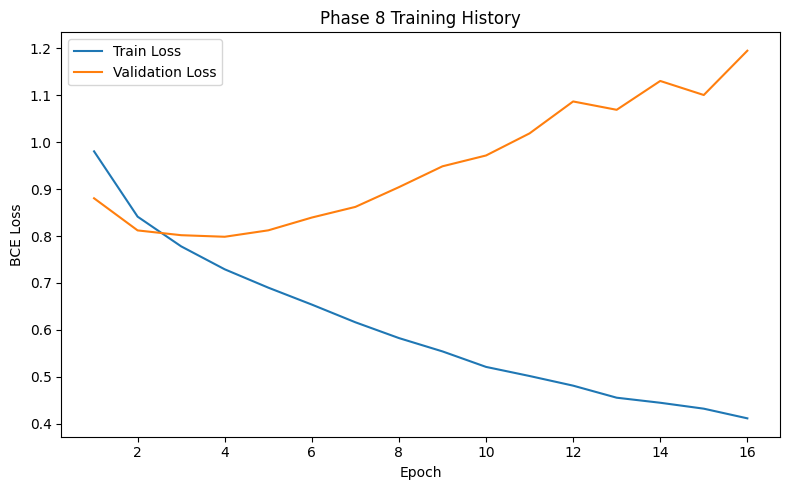

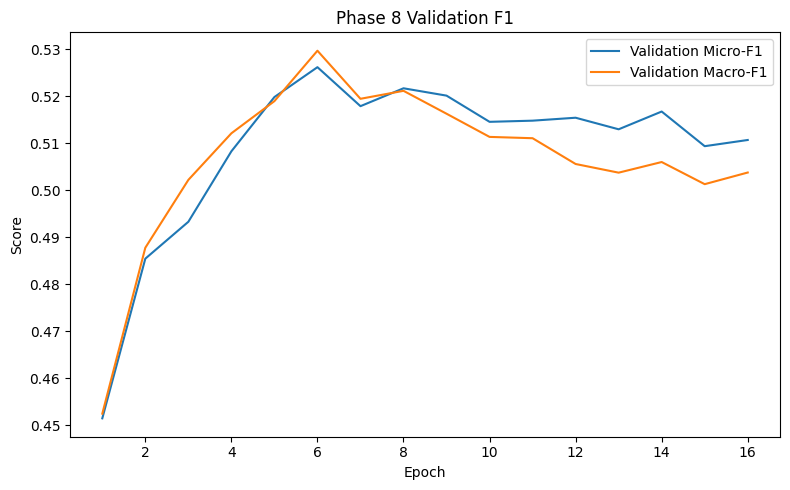

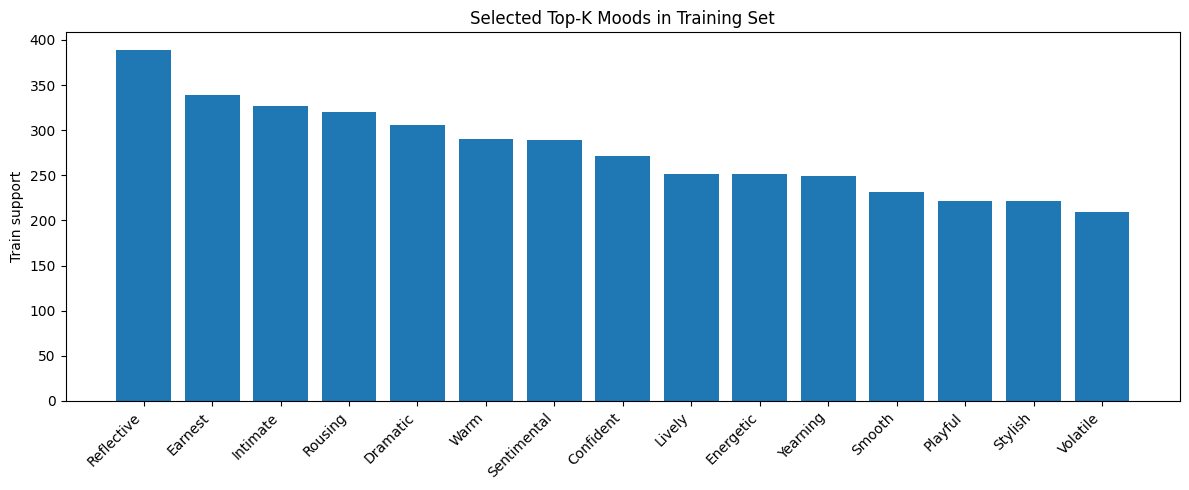

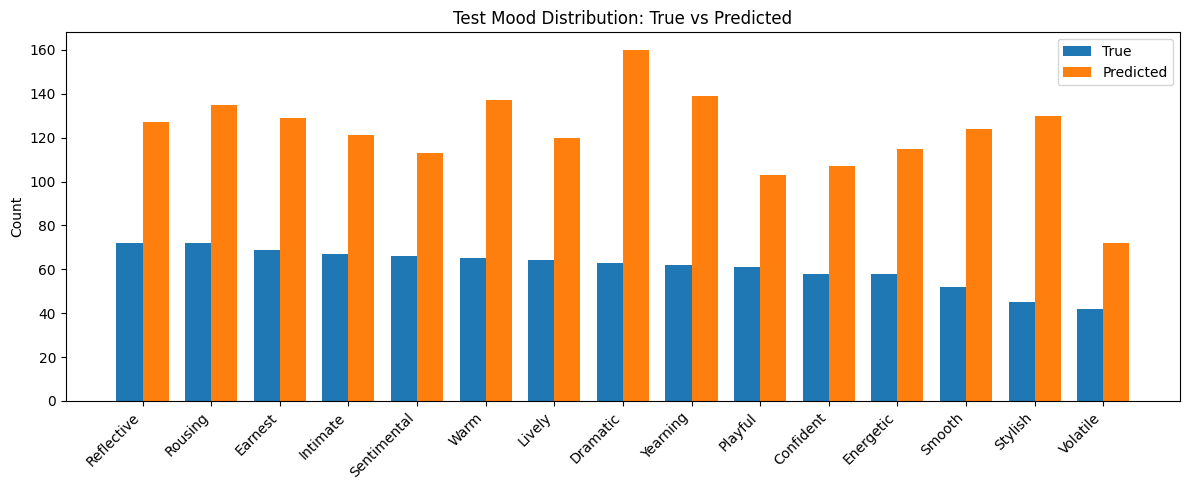

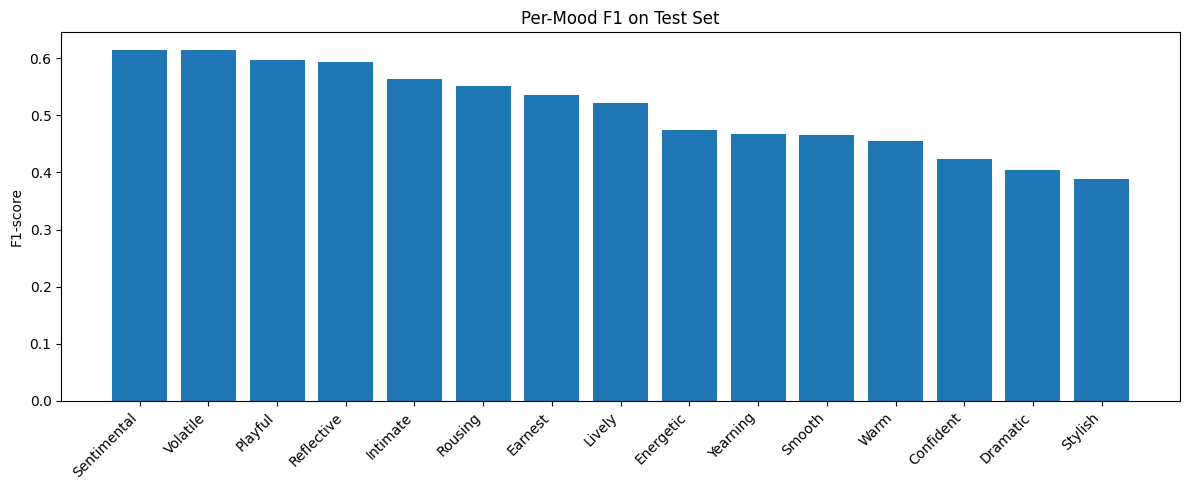


Phase 8 complete.
Artifacts saved in: /content/data/phase8_direct_mood_prediction
Plots saved in: /content/data/phase8_direct_mood_prediction/plots

Selected moods:
['Reflective', 'Rousing', 'Warm', 'Sentimental', 'Intimate', 'Earnest', 'Yearning', 'Smooth', 'Lively', 'Playful', 'Dramatic', 'Confident', 'Energetic', 'Stylish', 'Volatile']


In [ ]:

# -----------------------------
# 24. Plot: training history
# -----------------------------
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Phase 8 Training History")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_history_loss.png", dpi=300)
plt.show()

# Plot validation F1 metrics
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_micro_f1"], label="Validation Micro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Phase 8 Validation F1")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_history_f1.png", dpi=300)
plt.show()

# -----------------------------
# 25. Plot: selected mood support
# -----------------------------
# Show how frequent each selected mood is in training
support_series = pd.Series(
    y_train_binary.sum(axis=0),
    index=top_moods
).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(support_series.index, support_series.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Train support")
plt.title("Selected Top-K Moods in Training Set")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "selected_mood_support.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 26. Plot: true vs predicted mood counts on test
# -----------------------------
# Compare distribution of true and predicted moods on test set
true_counts = pd.Series(
    test_results["y_true_binary"].sum(axis=0),
    index=top_moods
).sort_values(ascending=False)

pred_counts = pd.Series(
    test_results["y_pred_binary"].sum(axis=0),
    index=top_moods
).reindex(true_counts.index)

x = np.arange(len(true_counts))
width = 0.38

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, true_counts.values, width, label="True")
plt.bar(x + width / 2, pred_counts.values, width, label="Predicted")
plt.xticks(x, true_counts.index, rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Test Mood Distribution: True vs Predicted")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "true_vs_predicted_mood_counts.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 27. Plot: per-label F1 on test
# -----------------------------
# Plot F1-score for each mood label
test_report_df = test_results["report_df"].copy()
per_label_f1 = test_report_df.loc[top_moods, "f1-score"].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(per_label_f1.index, per_label_f1.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Per-Mood F1 on Test Set")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_mood_f1.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 28. Save readable mood lists per song
# -----------------------------
# Helper to convert binary predictions back into readable mood names
def decode_predicted_labels(pred_row, mood_names):
    return [mood for mood, flag in zip(mood_names, pred_row) if flag == 1]

# Save true and predicted labels in readable text format
readable_predictions_df = pd.DataFrame({
    "song_id": test_song_ids,
    "true_moods": [
        ",".join(decode_predicted_labels(row, top_moods))
        for row in test_results["y_true_binary"]
    ],
    "pred_moods": [
        ",".join(decode_predicted_labels(row, top_moods))
        for row in test_results["y_pred_binary"]
    ]
})

readable_predictions_df.to_csv(PHASE8_DIR / "phase8_test_predictions_readable.csv", index=False)

# -----------------------------
# 29. Final summary
# -----------------------------
# Final confirmation of saved outputs
print("\nPhase 8 complete.")
print("Artifacts saved in:", PHASE8_DIR)
print("Plots saved in:", PLOTS_DIR)
print("\nSelected moods:")
print(top_moods)

## Phase 9 — Evaluation

I compared the results from the baseline models, the multimodal model, the valence-arousal mapping approach, and the direct mood prediction model. I used this phase to summarize the overall performance of the project and identify which approach worked best.


VA Prediction Comparison:


,Model,Target,MSE,RMSE,MAE,R2
0,Lyrics-only,Valence,0.028379,0.168460,0.134535,0.451096
1,Lyrics-only,Arousal,0.013736,0.117199,0.088327,0.275950
2,Audio-only,Valence,0.034776,0.186482,0.151932,0.327365
3,Audio-only,Arousal,0.010914,0.104470,0.078333,0.424690
4,Multimodal (Initial),Valence,0.027088,0.164586,0.129209,0.491198
5,Multimodal (Initial),Arousal,0.009992,0.099958,0.073777,0.483458
6,Multimodal (Tuned),Valence,0.028688,0.169374,0.116482,0.461162
7,Multimodal (Tuned),Arousal,0.008874,0.094201,0.069297,0.541238


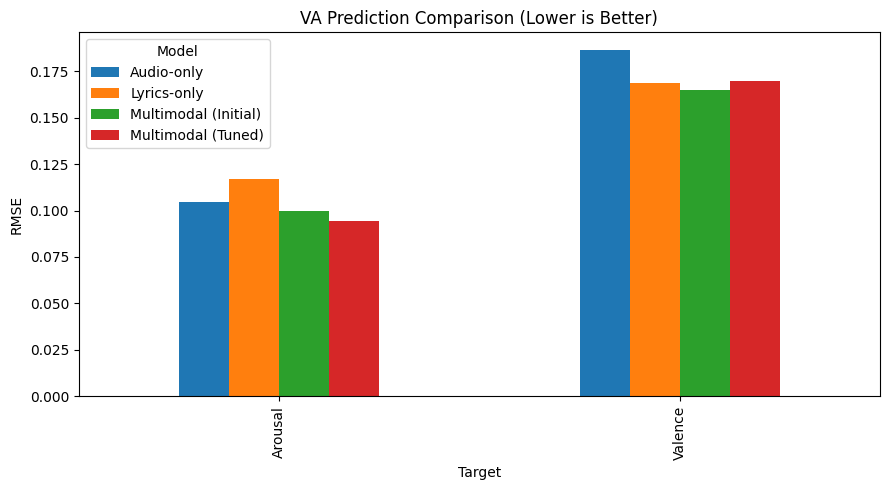

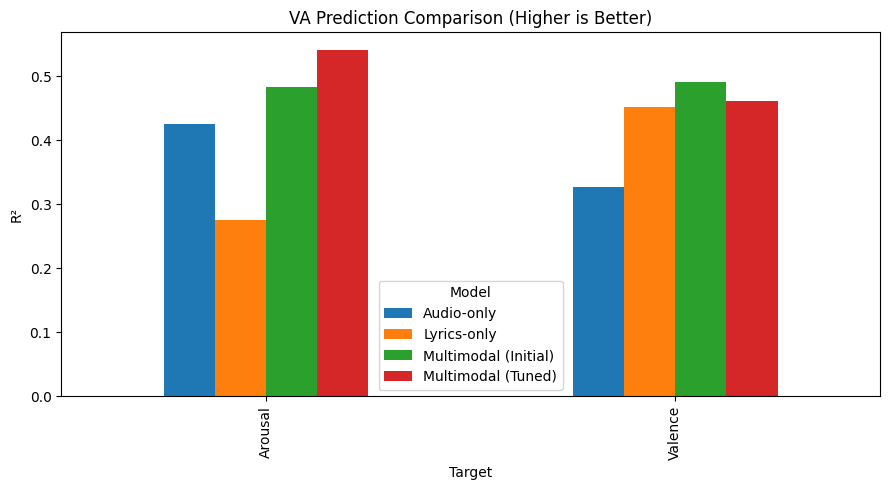


Best VA model by target:


,Target,Best RMSE Model,Best RMSE,Best R2 Model,Best R2
0,Valence,Multimodal (Initial),0.164586,Multimodal (Initial),0.491198
1,Arousal,Multimodal (Tuned),0.094201,Multimodal (Tuned),0.541238



Overall VA model ranking:


,Model,rmse_rank,r2_rank,combined_rank
0,Multimodal (Initial),1.5,1.5,3.0
1,Multimodal (Tuned),2.0,1.5,3.5
2,Lyrics-only,3.0,3.5,6.5
3,Audio-only,3.5,3.5,7.0


In [ ]:
# ============================================================
# PHASE 9 — FINAL EVALUATION
# Goal:
#   Compare all main approaches:
#     - Audio-only vs Lyrics-only vs Initial Multimodal vs Final Tuned Multimodal
#       for valence-arousal regression
#     - VA Mapping vs Direct Mood Prediction for multi-label classification
#
# This phase:
#   1) loads results from previous phases
#   2) compares models for VA prediction
#   3) compares approaches for emotion prediction
#   4) ranks models and approaches
#   5) generates final summary tables and plots
#
# Inputs:
#   - baseline_results.csv (Phase 3)
#   - multimodal_results.csv (Phase 4)
#   - final_test_metrics.csv (Phase 6)
#   - emotion_mapping_metrics.csv (Phase 7)
#   - phase8_summary_metrics.csv (Phase 8)
#
# Outputs:
#   - va_comparison.csv
#   - va_rmse_comparison.png
#   - va_r2_comparison.png
#   - best_va_by_target.csv
#   - overall_va_model_ranking.csv
#   - emotion_comparison.csv
#   - emotion_f1_comparison.png
#   - emotion_accuracy_hamming.png
#   - emotion_best_by_metric.csv
#   - emotion_overall_ranking.csv
#   - final_summary.csv
# ============================================================

# -----------------------------
# 1. Imports
# -----------------------------
# Data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 2. Paths
# -----------------------------
# Define directories for all phase outputs
DATA_DIR = Path("/content/data")

PHASE3_DIR = DATA_DIR / "phase3_baselines"
PHASE4_DIR = DATA_DIR / "phase4_multimodal_model"
PHASE6_DIR = DATA_DIR / "phase6_final_tuned_multimodal_model"
PHASE7_DIR = DATA_DIR / "phase7_emotion_mapping"
PHASE8_DIR = DATA_DIR / "phase8_direct_mood_prediction"

PHASE9_DIR = DATA_DIR / "phase9_final_evaluation"
PLOTS_DIR = PHASE9_DIR / "plots"

# Create output folders
PHASE9_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# PART 1 — VA PREDICTION COMPARISON
# ============================================================

# -----------------------------
# 3. Load baseline results (Phase 3)
# -----------------------------
# Load audio-only and lyrics-only baseline results
baseline_df = pd.read_csv(PHASE3_DIR / "baseline_results.csv")

# Keep only relevant columns for comparison
baseline_df = baseline_df[["Model", "Target", "MSE", "RMSE", "MAE", "R2"]].copy()

# -----------------------------
# 4. Load initial multimodal results (Phase 4)
# -----------------------------
# Load initial multimodal model results
phase4_df = pd.read_csv(PHASE4_DIR / "multimodal_results.csv")

# Keep only test results
phase4_test = phase4_df[phase4_df["target"].str.contains("test")].copy()

# Rename model and target labels
phase4_test["Model"] = "Multimodal (Initial)"
phase4_test["Target"] = phase4_test["target"].apply(
    lambda x: "Valence" if "valence" in x.lower() else "Arousal"
)

# Keep consistent columns
phase4_test = phase4_test[["Model", "Target", "MSE", "RMSE", "MAE", "R2"]]

# -----------------------------
# 5. Load final tuned multimodal results (Phase 6)
# -----------------------------
# Load final tuned model results
phase6_df = pd.read_csv(PHASE6_DIR / "final_test_metrics.csv").copy()

# Rename model and targets
phase6_df["Model"] = "Multimodal (Tuned)"
phase6_df["Target"] = phase6_df["target"].apply(
    lambda x: "Valence" if "valence" in x.lower() else "Arousal"
)

phase6_df = phase6_df[["Model", "Target", "MSE", "RMSE", "MAE", "R2"]]

# -----------------------------
# 6. Combine all VA results
# -----------------------------
# Merge baseline, initial, and tuned results
va_results = pd.concat(
    [baseline_df, phase4_test, phase6_df],
    ignore_index=True
)

print("\nVA Prediction Comparison:")
display(va_results)

# Save combined table
va_results.to_csv(PHASE9_DIR / "va_comparison.csv", index=False)

# -----------------------------
# 7. Plot: RMSE comparison
# -----------------------------
# Compare RMSE across models
rmse_df = va_results.pivot(index="Target", columns="Model", values="RMSE")

rmse_df.plot(kind="bar", figsize=(9, 5))
plt.ylabel("RMSE")
plt.title("VA Prediction Comparison (Lower is Better)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "va_rmse_comparison.png", dpi=300)
plt.show()

# -----------------------------
# 8. Plot: R2 comparison
# -----------------------------
# Compare R² across models
r2_df = va_results.pivot(index="Target", columns="Model", values="R2")

r2_df.plot(kind="bar", figsize=(9, 5))
plt.ylabel("R²")
plt.title("VA Prediction Comparison (Higher is Better)")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "va_r2_comparison.png", dpi=300)
plt.show()

# -----------------------------
# 9. Best VA model by target
# -----------------------------
# Find best model for each target (Valence / Arousal)
best_va_by_target = []

for target in ["Valence", "Arousal"]:
    subset = va_results[va_results["Target"] == target].copy()

    best_rmse_row = subset.loc[subset["RMSE"].idxmin()]
    best_r2_row = subset.loc[subset["R2"].idxmax()]

    best_va_by_target.append({
        "Target": target,
        "Best RMSE Model": best_rmse_row["Model"],
        "Best RMSE": best_rmse_row["RMSE"],
        "Best R2 Model": best_r2_row["Model"],
        "Best R2": best_r2_row["R2"]
    })

best_va_by_target_df = pd.DataFrame(best_va_by_target)

print("\nBest VA model by target:")
display(best_va_by_target_df)

best_va_by_target_df.to_csv(PHASE9_DIR / "best_va_by_target.csv", index=False)

# -----------------------------
# 10. Overall VA ranking
# -----------------------------
# Rank models using RMSE and R²
va_rank_df = va_results.copy()
va_rank_df["rmse_rank"] = va_rank_df.groupby("Target")["RMSE"].rank(method="min", ascending=True)
va_rank_df["r2_rank"] = va_rank_df.groupby("Target")["R2"].rank(method="min", ascending=False)
va_rank_df["combined_rank"] = va_rank_df["rmse_rank"] + va_rank_df["r2_rank"]

# Compute overall ranking
overall_va_ranking = (
    va_rank_df.groupby("Model")[["rmse_rank", "r2_rank", "combined_rank"]]
    .mean()
    .sort_values("combined_rank")
    .reset_index()
)

overall_va_best_model = overall_va_ranking.iloc[0]["Model"]

print("\nOverall VA model ranking:")
display(overall_va_ranking)

overall_va_ranking.to_csv(PHASE9_DIR / "overall_va_model_ranking.csv", index=False)





Emotion Prediction Comparison:


,micro_f1,macro_f1,weighted_f1,samples_f1,exact_match_accuracy,hamming_loss,Approach
0,0.587252,0.369288,0.568753,0.580794,0.463333,0.114493,VA Mapping
1,0.508006,0.511343,0.514288,0.470604,0.026667,0.300444,Direct Prediction


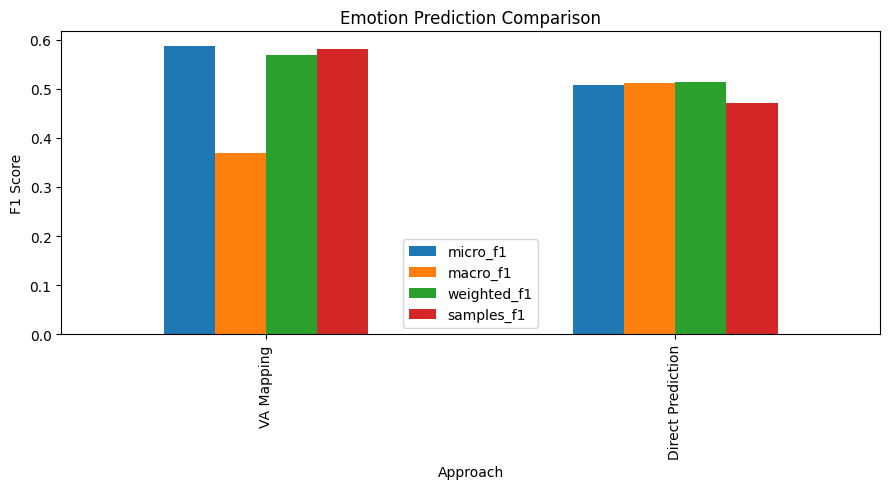

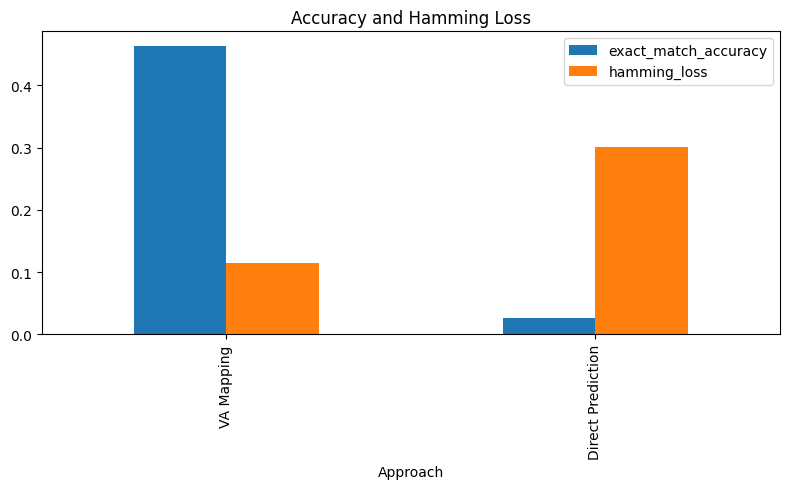


Best emotion approach by metric:


,Metric,Best Approach
0,micro_f1,VA Mapping
1,macro_f1,Direct Prediction
2,weighted_f1,VA Mapping
3,samples_f1,VA Mapping
4,exact_match_accuracy,VA Mapping
5,hamming_loss,VA Mapping



Overall emotion approach ranking:


,Approach,micro_f1_rank,macro_f1_rank,weighted_f1_rank,samples_f1_rank,accuracy_rank,hamming_rank,combined_rank
0,VA Mapping,1.0,2.0,1.0,1.0,1.0,1.0,7.0
1,Direct Prediction,2.0,1.0,2.0,2.0,2.0,2.0,11.0


In [ ]:
# ============================================================
# PART 2 — EMOTION PREDICTION COMPARISON
# ============================================================

# -----------------------------
# 11. Load Phase 7 (VA mapping)
# -----------------------------
# Load emotion mapping results
phase7_metrics = pd.read_csv(PHASE7_DIR / "emotion_mapping_metrics.csv")
phase7_metrics["Approach"] = "VA Mapping"

# -----------------------------
# 12. Load Phase 8 (Direct mood prediction)
# -----------------------------
# Load direct prediction results (test only)
phase8_metrics = pd.read_csv(PHASE8_DIR / "phase8_summary_metrics.csv")

phase8_test = phase8_metrics[phase8_metrics["split"] == "test"].copy()
phase8_test["Approach"] = "Direct Prediction"

# -----------------------------
# 13. Align columns
# -----------------------------
# Ensure both approaches use same metric columns
common_cols = [
    "micro_f1",
    "macro_f1",
    "weighted_f1",
    "samples_f1",
    "exact_match_accuracy",
    "hamming_loss"
]

phase7_metrics = phase7_metrics[common_cols + ["Approach"]]
phase8_test = phase8_test[common_cols + ["Approach"]]

emotion_results = pd.concat([phase7_metrics, phase8_test], ignore_index=True)

print("\nEmotion Prediction Comparison:")
display(emotion_results)

emotion_results.to_csv(PHASE9_DIR / "emotion_comparison.csv", index=False)

# -----------------------------
# 14. Plot: F1 comparison
# -----------------------------
# Compare different F1 metrics
f1_plot_df = emotion_results.set_index("Approach")[["micro_f1", "macro_f1", "weighted_f1", "samples_f1"]]

f1_plot_df.plot(kind="bar", figsize=(9, 5))
plt.ylabel("F1 Score")
plt.title("Emotion Prediction Comparison")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "emotion_f1_comparison.png", dpi=300)
plt.show()

# -----------------------------
# 15. Plot: Accuracy + Hamming Loss
# -----------------------------
# Compare accuracy and hamming loss
metric_plot_df = emotion_results.set_index("Approach")[["exact_match_accuracy", "hamming_loss"]]

metric_plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("Accuracy and Hamming Loss")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "emotion_accuracy_hamming.png", dpi=300)
plt.show()

# -----------------------------
# 16. Emotion summary by metric
# -----------------------------
# Determine best approach for each metric
best_micro_f1 = emotion_results.loc[emotion_results["micro_f1"].idxmax(), "Approach"]
best_macro_f1 = emotion_results.loc[emotion_results["macro_f1"].idxmax(), "Approach"]
best_weighted_f1 = emotion_results.loc[emotion_results["weighted_f1"].idxmax(), "Approach"]
best_samples_f1 = emotion_results.loc[emotion_results["samples_f1"].idxmax(), "Approach"]
best_accuracy = emotion_results.loc[emotion_results["exact_match_accuracy"].idxmax(), "Approach"]
best_hamming = emotion_results.loc[emotion_results["hamming_loss"].idxmin(), "Approach"]

emotion_metric_summary = pd.DataFrame([
    {"Metric": "micro_f1", "Best Approach": best_micro_f1},
    {"Metric": "macro_f1", "Best Approach": best_macro_f1},
    {"Metric": "weighted_f1", "Best Approach": best_weighted_f1},
    {"Metric": "samples_f1", "Best Approach": best_samples_f1},
    {"Metric": "exact_match_accuracy", "Best Approach": best_accuracy},
    {"Metric": "hamming_loss", "Best Approach": best_hamming}
])

print("\nBest emotion approach by metric:")
display(emotion_metric_summary)

emotion_metric_summary.to_csv(PHASE9_DIR / "emotion_best_by_metric.csv", index=False)

# -----------------------------
# 17. Overall emotion ranking
# -----------------------------
# Rank approaches across all metrics
emotion_rank_df = emotion_results.copy()

emotion_rank_df["micro_f1_rank"] = emotion_rank_df["micro_f1"].rank(method="min", ascending=False)
emotion_rank_df["macro_f1_rank"] = emotion_rank_df["macro_f1"].rank(method="min", ascending=False)
emotion_rank_df["weighted_f1_rank"] = emotion_rank_df["weighted_f1"].rank(method="min", ascending=False)
emotion_rank_df["samples_f1_rank"] = emotion_rank_df["samples_f1"].rank(method="min", ascending=False)
emotion_rank_df["accuracy_rank"] = emotion_rank_df["exact_match_accuracy"].rank(method="min", ascending=False)
emotion_rank_df["hamming_rank"] = emotion_rank_df["hamming_loss"].rank(method="min", ascending=True)

emotion_rank_df["combined_rank"] = (
    emotion_rank_df["micro_f1_rank"]
    + emotion_rank_df["macro_f1_rank"]
    + emotion_rank_df["weighted_f1_rank"]
    + emotion_rank_df["samples_f1_rank"]
    + emotion_rank_df["accuracy_rank"]
    + emotion_rank_df["hamming_rank"]
)

emotion_overall_ranking = emotion_rank_df[
    [
        "Approach",
        "micro_f1_rank",
        "macro_f1_rank",
        "weighted_f1_rank",
        "samples_f1_rank",
        "accuracy_rank",
        "hamming_rank",
        "combined_rank"
    ]
].sort_values("combined_rank").reset_index(drop=True)

print("\nOverall emotion approach ranking:")
display(emotion_overall_ranking)

emotion_overall_ranking.to_csv(PHASE9_DIR / "emotion_overall_ranking.csv", index=False)


In [ ]:
# ============================================================
# PART 3 — FINAL SUMMARY TABLE
# ============================================================

# -----------------------------
# 18. Final summary table
# -----------------------------
# Summarize best approaches for each task
final_summary = pd.DataFrame([
    {
        "Task": "VA Prediction",
        "Best Model": overall_va_best_model,
        "Insight": "Compare models using RMSE and R²."
    },
    {
        "Task": "Emotion Prediction",
        "Best Model": "Depends on metric",
        "Insight": "Compare VA Mapping vs Direct Prediction using F1, accuracy, and hamming loss."
    }
])

print("\nFinal Summary:")
display(final_summary)

final_summary.to_csv(PHASE9_DIR / "final_summary.csv", index=False)

# -----------------------------
# 19. Final summary
# -----------------------------
# Final confirmation
print("\nPhase 9 complete.")
print("Artifacts saved in:", PHASE9_DIR)
print("Plots saved in:", PLOTS_DIR)


Final Summary:


,Task,Best Model,Insight
0,VA Prediction,Multimodal (Initial),Compare models using RMSE and R².
1,Emotion Prediction,Depends on metric,Compare VA Mapping vs Direct Prediction using ...



Phase 9 complete.
Artifacts saved in: /content/data/phase9_final_evaluation
Plots saved in: /content/data/phase9_final_evaluation/plots
